In [508]:
from logging import warn
import requests
import pandas as pd
import json
from datetime import datetime, timedelta
import time
import warnings
import numpy as np

warnings.filterwarnings("ignore")

In [288]:
class PolymarketDataFetcher:
    def __init__(self):
        self.clob_url = "https://clob.polymarket.com"
        self.gamma_url = "https://gamma-api.polymarket.com"

    def search_crypto_15min_markets(self, limit=100, days_lookback=5):
        """Search for active crypto 15-minute prediction markets"""
        end_date = pd.to_datetime(datetime.now()).floor("h")
        datetime_index = pd.date_range(
            start=end_date - timedelta(days=days_lookback),
            end=end_date,
            freq=timedelta(minutes=15),
        )
        timestamps = [int(time.timestamp()) for time in list(datetime_index)]

        # slugs_prefix = [
        #     "btc-updown-15m-",
        #     "eth-updown-15m-",
        #     "sol-updown-15m-",
        #     "xrp-updown-15m-",
        # ]
        slug_prefix = "btc-updown-15m-"
        crypto_markets = []
        for time in timestamps:
            slug = f"{slug_prefix}{time}"
            url = f"{self.gamma_url}/events"
            params = {
                "limit": limit,
                "active": "true",  # Only active markets
                "slug": slug,
            }
            response = requests.get(url, params=params)
            events = response.json()

            for event in events:
                market = event.get("markets", [])[0]
                crypto_markets.append(
                    {
                        "condition_id": market["conditionId"],
                        "question": market["question"],
                        "market_slug": market.get("slug", ""),
                        "end_date": market.get("endDate"),
                        "tokens": market.get("clobTokenIds", []),
                    }
                )

        return pd.DataFrame(crypto_markets), timestamps

    def get_market_prices(self, token_ids, start_ts=None, end_ts=None):
        """
        Get historical price data for both YES and NO tokens

        Args:
            token_ids: List of [yes_token_id, no_token_id]
            start_ts: Start timestamp (unix seconds)
            end_ts: End timestamp (unix seconds)
            interval: Time interval (1m, 5m, 15m, 1h, etc.)
        """
        # Default to last 7 days if no timestamps provided
        if end_ts is None:
            end_ts = int(time.time())
        if start_ts is None:
            start_ts = end_ts - timedelta(days=7).total_seconds()

        # Fetch YES token prices
        yes_data = self._fetch_token_prices(token_ids[0], start_ts, end_ts)
        # Fetch NO token prices
        no_data = self._fetch_token_prices(token_ids[1], start_ts, end_ts)

        return self._merge_price_data(yes_data, no_data)

    def _fetch_token_prices(self, token_id, start_ts, end_ts):
        """Fetch prices for a single token"""
        url = f"{self.clob_url}/prices-history"
        params = {
            "market": token_id,
            "startTs": start_ts,
            "endTs": end_ts,
        }

        response = requests.get(url, params=params)
        return response.json()

    def _merge_price_data(self, yes_data, no_data):
        """Merge YES and NO token prices into single DataFrame"""
        yes_records = []
        no_records = []

        if yes_data and "history" in yes_data:
            for entry in yes_data["history"]:
                yes_records.append(
                    {
                        "timestamp": datetime.fromtimestamp(entry["t"]),
                        "yes_price": float(entry["p"]),
                    }
                )

        if no_data and "history" in no_data:
            for entry in no_data["history"]:
                no_records.append(
                    {
                        "timestamp": datetime.fromtimestamp(entry["t"]),
                        "no_price": float(entry["p"]),
                    }
                )

        yes_df = pd.DataFrame(yes_records)
        no_df = pd.DataFrame(no_records)

        if yes_df.empty or no_df.empty:
            return pd.DataFrame()

        # Merge on timestamp to align prices
        df = pd.merge(yes_df, no_df, on="timestamp", how="outer")
        df = df.sort_values("timestamp").reset_index(drop=True)

        # Forward fill missing values
        df["yes_price"] = df["yes_price"].fillna(method="ffill")
        df["no_price"] = df["no_price"].fillna(method="ffill")

        # Calculate arbitrage opportunities
        df["price_sum"] = df["yes_price"] + df["no_price"]
        df["arb_opportunity"] = abs(df["price_sum"] - 1.0)

        return df

    def get_order_book_snapshot(self, token_id):
        """Get current order book for a token"""
        url = f"{self.gamma_url}/orderbook"
        params = {"token_id": token_id}

        response = requests.get(url, params=params)
        return response.json()

    def get_trades(self, condition_id, limit=100):
        """Get recent trades for a market"""
        url = f"{self.clob_url}/data/trades"
        params = {"market": condition_id, "limit": limit}

        response = requests.get(url, params=params)
        trades = response.json()

        records = []
        for trade in trades:
            print(trade)
            records.append(
                {
                    "timestamp": datetime.fromtimestamp(int(trade["timestamp"])),
                    "price": float(trade["price"]),
                    "size": float(trade["size"]),
                    "side": trade["side"],
                }
            )

        return pd.DataFrame(records)

    def backtest_dataset(self, token_ids, end_date=None):
        """
        Create a comprehensive dataset for backtesting

        Args:
            condition_id: Market condition ID
            token_ids: List of [yes_token_id, no_token_id]
            days_back: Number of days of historical data
        """
        if end_date is not None:
            end_ts = datetime.strptime(end_date, "%Y-%m-%dT%H:%M:%SZ").timestamp()
        else:
            end_ts = time.time()

        start_ts = end_ts - timedelta(days=1).total_seconds()

        prices = self.get_market_prices(token_ids, start_ts, end_ts)
        start_date = (
            datetime.fromtimestamp(end_ts)
            - timedelta(minutes=30)
            - timedelta(hours=5)
        )  # convert from UTC to EST
        prices_trimmed = prices[prices["timestamp"] >= start_date]

        if prices_trimmed.empty:
            print("No price data found")
            return None

        # Add derived features for backtesting
        prices_trimmed["spread"] = abs(
            prices_trimmed["yes_price"] - prices_trimmed["no_price"]
        )

        # Stat arb signals
        prices_trimmed["arb_size"] = (
            prices_trimmed["price_sum"] - 1.0
        )  # Positive = overpriced, negative = underpriced
        prices_trimmed["arb_signal"] = (prices_trimmed["arb_size"] > 0.01).astype(
            int
        ) - (prices_trimmed["arb_size"] < -0.01).astype(int)

        return prices_trimmed

    def export_to_csv(self, df, filename):
        """Export data to CSV"""
        df.to_csv(filename, index=False)
        print(f"Data exported to {filename}")


In [294]:
# Example usage
if __name__ == "__main__":
    fetcher = PolymarketDataFetcher()

    # 1. Search for active 15-minute crypto markets
    print("Searching for crypto 15-minute markets...")
    markets, market_timestamps = fetcher.search_crypto_15min_markets(days_lookback=1)
    print(f"\nFound {len(markets)} markets:")
    display(markets.head())

    prices_dict = {}
    # 2. Get historical data for backtesting
    if not markets.empty:
        for market in markets.itertuples():
            condition_id = market.condition_id
            token_ids = json.loads(market.tokens)  # Get YES and NO token IDs

            # Get 7 days of 1-minute data
            prices = fetcher.backtest_dataset(
                token_ids, end_date=market.end_date
            )

            prices_dict[market.market_slug] = prices

            # if prices is not None:
            #     print(f"\nRetrieved {len(prices)} price points")
            #     print("\nSample data:")
            #     display(prices.head(10))

            #     # Show arbitrage opportunities
            #     arb_opps = prices[prices["arb_opportunity"] > 0.01]
            #     print(
            #         f"\nFound {len(arb_opps)} arbitrage opportunities (>1% deviation from 1.0)"
            #     )
            #     if not arb_opps.empty:
            #         display(
            #             arb_opps[
            #                 [
            #                     "timestamp",
            #                     "yes_price",
            #                     "no_price",
            #                     "price_sum",
            #                     "arb_opportunity",
            #                 ]
            #             ].head()
            #         )

        prices_combined = (
            pd.concat(prices_dict)
            .reset_index(drop=False)
            .rename(columns={"level_0": "market_slug"})
            .drop(columns=["level_1"])
        )

        # Export for backtesting
        fetcher.export_to_csv(prices_combined, "polymarket_backtest_data.csv")

        # # Get recent trades
        # print("\nFetching recent trades...")
        # trades = fetcher.get_trades(condition_id, limit=50)
        # if not trades.empty:
        #     print(f"Retrieved {len(trades)} trades")
        #     print(trades.head())


Searching for crypto 15-minute markets...

Found 97 markets:


,condition_id,question,market_slug,end_date,tokens
0,0x6827a473b953968f90cb145f5cf3a68a068d5dc6439c...,"Bitcoin Up or Down - January 15, 1:00PM-1:15PM ET",btc-updown-15m-1768500000,2026-01-15T18:15:00Z,"[""73822119959704620432325274157473032959094751..."
1,0x5b81f07b5368a52d2e9b480a859bb9fd95d214bae913...,"Bitcoin Up or Down - January 15, 1:15PM-1:30PM ET",btc-updown-15m-1768500900,2026-01-15T18:30:00Z,"[""96513841046848622856988175789389545930188031..."
2,0xf3966dc7736e7e3dd069968749042476d2d0c562f513...,"Bitcoin Up or Down - January 15, 1:30PM-1:45PM ET",btc-updown-15m-1768501800,2026-01-15T18:45:00Z,"[""47728470309359763136506030165614937875065968..."
3,0xb64f659f91877237b552a6c3846caf22fa381249ea98...,"Bitcoin Up or Down - January 15, 1:45PM-2:00PM ET",btc-updown-15m-1768502700,2026-01-15T19:00:00Z,"[""32528224251188555183672742301073904752452999..."
4,0x7e0b3fdd1c58eb87aed17a0e54190fbd6144f8e77d66...,"Bitcoin Up or Down - January 15, 2:00PM-2:15PM ET",btc-updown-15m-1768503600,2026-01-15T19:15:00Z,"[""22080145010827082195220438734997479450853164..."


Data exported to polymarket_backtest_data.csv


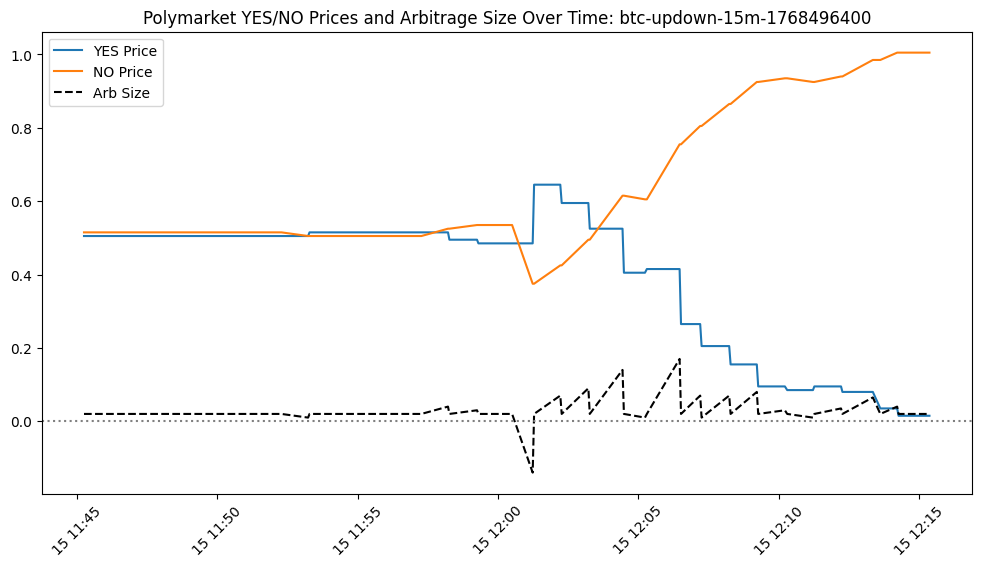

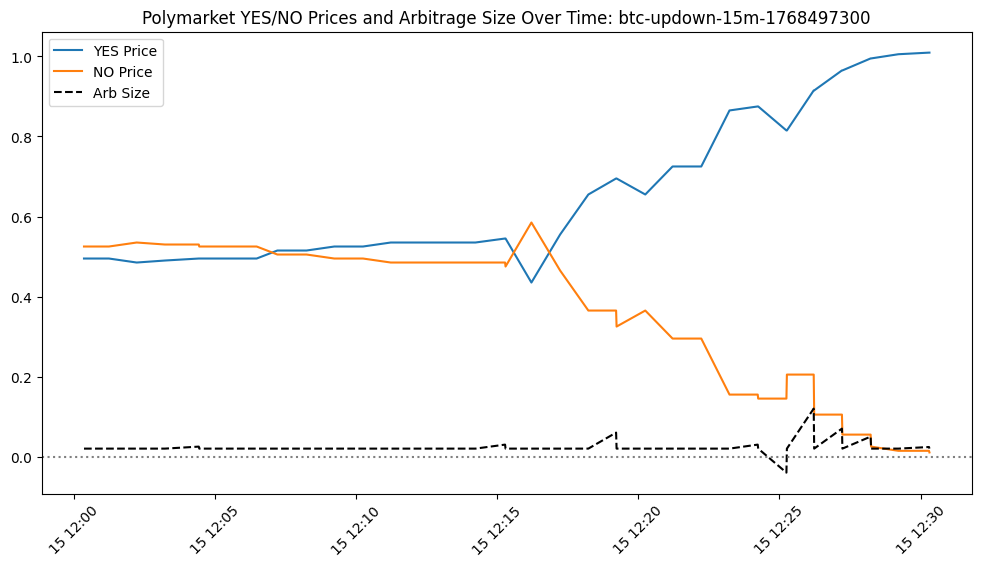

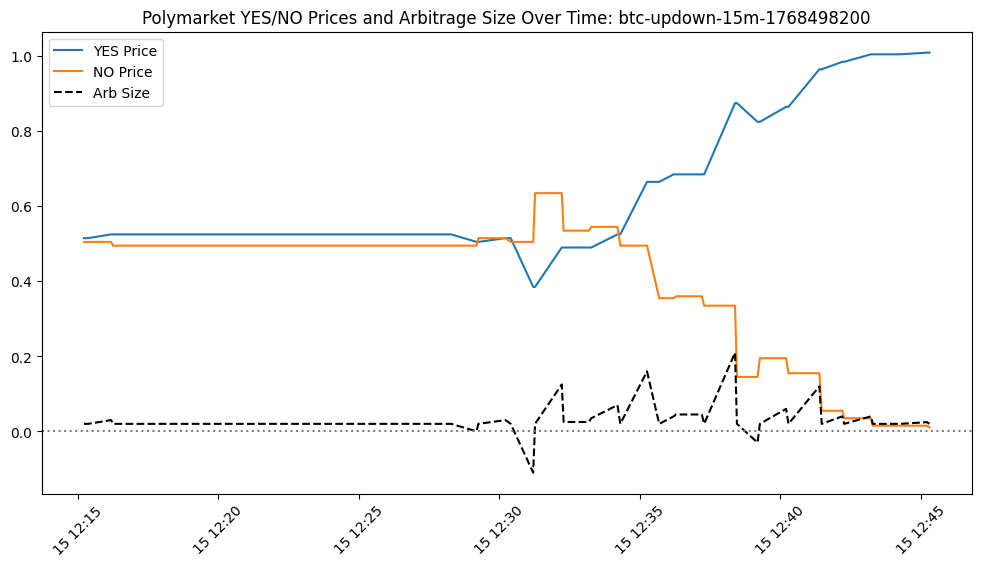

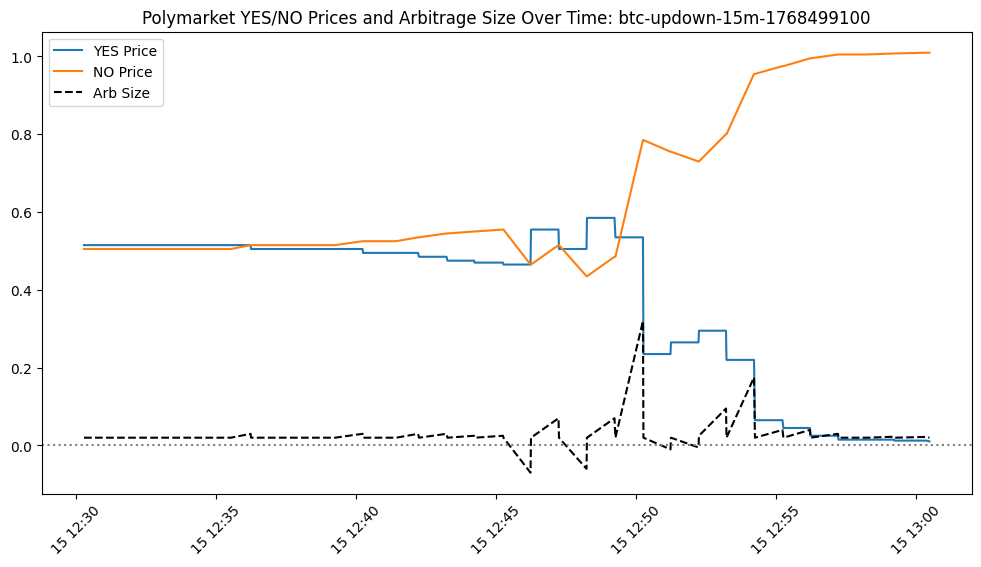

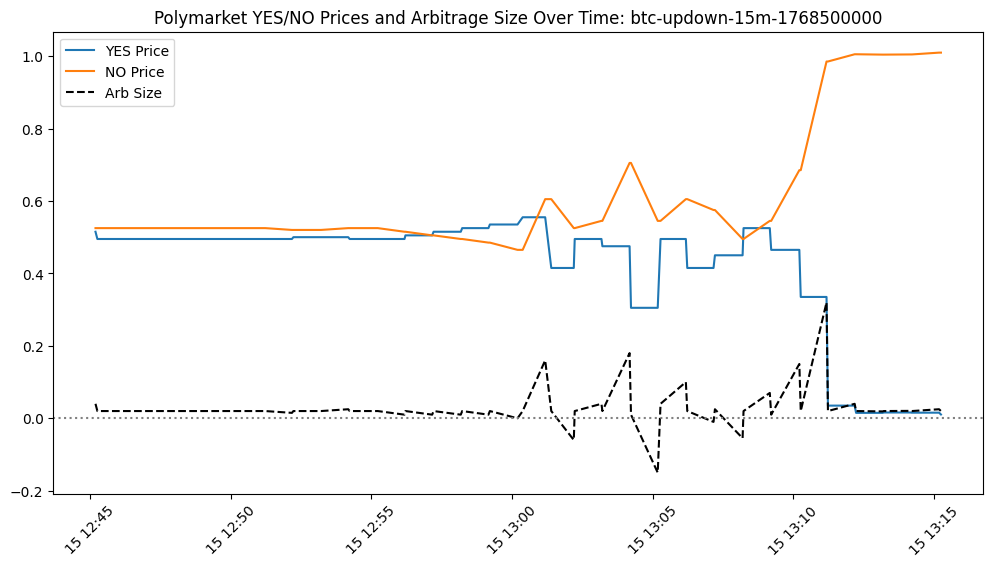

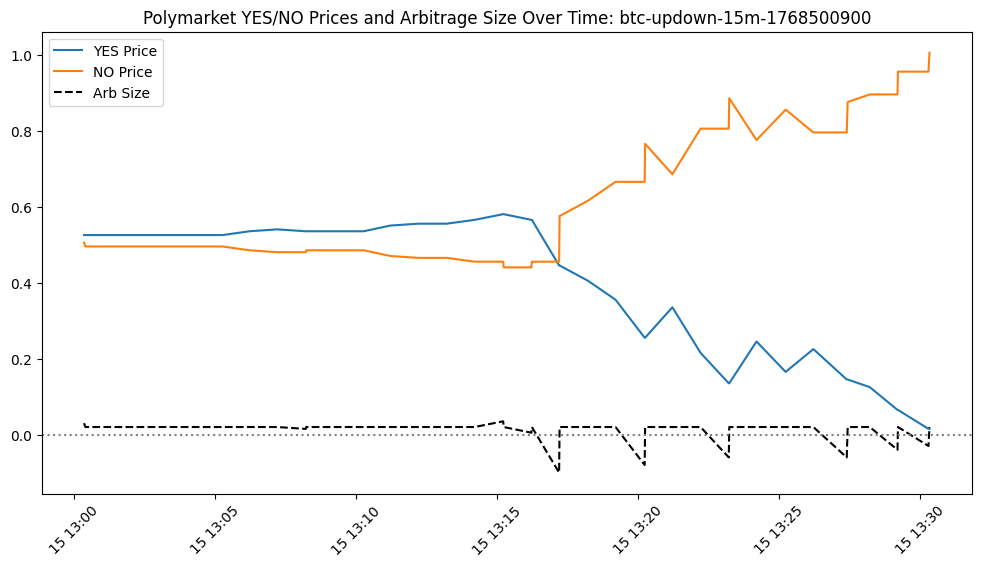

In [291]:
import matplotlib.pyplot as plt

counter = 0
for key, prices in prices_dict.items():
    if counter > 5:
        break  # Limit to first 8 timestamps for brevity

    plt.figure(figsize=(12, 6))
    plt.plot(
        prices["timestamp"], prices["yes_price"]+0.01, label="YES Price"
    )
    plt.plot(
        prices["timestamp"], prices["no_price"]+0.01, label="NO Price"
    )
    plt.plot(
        prices["timestamp"],
        prices["yes_price"]+0.01 + prices["no_price"]+0.01 - 1.0,
        label="Arb Size",
        linestyle="--",
        c="k",
    )
    plt.axhline(y=0, color="gray", linestyle=":")
    plt.title(f"Polymarket YES/NO Prices and Arbitrage Size Over Time: {key}")
    plt.xticks(rotation=45)
    plt.legend()
    counter += 1

### OrderBook Analysis

In [2]:
from pathlib import Path
import pandas as pd

data_dir = Path.cwd() / "data/external/polymarket/orderbooks"
# file_name = "btc-updown-15m-1768660200_orderbook.csv"
# file_name = "btc-updown-15m-1768884300_orderbook.csv"
file_name = "btc-updown-15m-1769116500_orderbook.csv"

df_orderbook = pd.read_csv(data_dir / file_name)
df_orderbook["datetime_utc"] = pd.to_datetime(df_orderbook["datetime_utc"])
df_orderbook["datetime_utc"] = df_orderbook["datetime_utc"].dt.floor('s')
df_orderbook

,datetime_utc,market_slug,resolution,type,price,size,token_id
0,2026-01-22 21:15:01,btc-updown-15m-1769116500,up,bid,0.01,11530.85,1458614623691161894797053887755072166956390151...
1,2026-01-22 21:15:01,btc-updown-15m-1769116500,up,bid,0.02,3429.18,1458614623691161894797053887755072166956390151...
2,2026-01-22 21:15:01,btc-updown-15m-1769116500,up,bid,0.03,1658.96,1458614623691161894797053887755072166956390151...
3,2026-01-22 21:15:01,btc-updown-15m-1769116500,up,bid,0.04,870.00,1458614623691161894797053887755072166956390151...
4,2026-01-22 21:15:01,btc-updown-15m-1769116500,up,bid,0.05,287.00,1458614623691161894797053887755072166956390151...
...,...,...,...,...,...,...,...
176119,2026-01-22 21:30:00,btc-updown-15m-1769116500,down,ask,0.05,5.00,1799388780503229044337309551975804704319455960...
176120,2026-01-22 21:30:00,btc-updown-15m-1769116500,down,ask,0.04,30.00,1799388780503229044337309551975804704319455960...
176121,2026-01-22 21:30:00,btc-updown-15m-1769116500,down,ask,0.03,951.73,1799388780503229044337309551975804704319455960...
176122,2026-01-22 21:30:00,btc-updown-15m-1769116500,down,ask,0.02,285.80,1799388780503229044337309551975804704319455960...


In [3]:
def cumulative_liquidity_at_timestamp(df, timestamp, resolution, order_type, max_price):
    """Calculate cumulative liquidity up to max_price for a specific timestamp"""
    book = df[
        (df["datetime_utc"] == timestamp)
        & (df["resolution"] == resolution)
        & (df["type"] == order_type)
    ]
    return book.loc[book["price"] <= max_price, "size"].astype(float).sum()

In [4]:
def get_best_quotes(df, resolution, datetime_col="datetime_utc"):
    """Extract best bid/ask for a given resolution (up/down) and sum of top 3 sizes"""
    data = df[df["resolution"] == resolution].copy()

    # Best ask (minimum price) and top 3 sum
    asks_data = data[data["type"] == "ask"].sort_values([datetime_col, "price"])
    asks_grouped = asks_data.groupby(datetime_col)

    asks_best = asks_grouped.first()[["price", "size"]].rename(
        columns={
            "price": f"{resolution}_best_ask_price",
            "size": f"{resolution}_best_ask_size",
        }
    )

    asks_top3 = (
        asks_grouped.head(3)
        .groupby(datetime_col)["size"]
        .sum()
        .rename(f"{resolution}_top3_ask_size")
    )

    asks = asks_best.join(asks_top3).reset_index()

    # Best bid (maximum price) and top 3 sum
    bids_data = data[data["type"] == "bid"].sort_values(
        [datetime_col, "price"], ascending=[True, False]
    )
    bids_grouped = bids_data.groupby(datetime_col)

    bids_best = bids_grouped.first()[["price", "size"]].rename(
        columns={
            "price": f"{resolution}_best_bid_price",
            "size": f"{resolution}_best_bid_size",
        }
    )

    bids_top3 = (
        bids_grouped.head(3)
        .groupby(datetime_col)["size"]
        .sum()
        .rename(f"{resolution}_top3_bid_size")
    )

    bids = bids_best.join(bids_top3).reset_index()

    return asks.merge(bids, on=datetime_col, how="outer")


def calculate_orderbook_features(df_orderbook):
    """Faster version using groupby instead of apply"""

    # Get best quotes
    up_best = get_best_quotes(df_orderbook, "up")
    down_best = get_best_quotes(df_orderbook, "down")
    best_prices = up_best.merge(down_best, on="datetime_utc", how="outer")

    best_prices["up_imbalance"] = (
        best_prices["up_best_bid_size"] - best_prices["up_best_ask_size"]
    ) / (best_prices["up_best_bid_size"] + best_prices["up_best_ask_size"])

    best_prices["down_imbalance"] = (
        best_prices["down_best_bid_size"] - best_prices["down_best_ask_size"]
    ) / (best_prices["down_best_bid_size"] + best_prices["down_best_ask_size"])

    best_prices["pair_best_ask"] = (
        best_prices["up_best_ask_price"] + best_prices["down_best_ask_price"]
    )
    best_prices["pair_best_bid"] = (
        best_prices["up_best_bid_price"] + best_prices["down_best_bid_price"]
    )
    best_prices["relative_imbalance"] = (
        best_prices["up_imbalance"] - best_prices["down_imbalance"]
    )

    best_prices["up_spread"] = (
        best_prices["up_best_ask_price"] - best_prices["up_best_bid_price"]
    )
    best_prices["up_mid"] = (
        best_prices["up_best_ask_price"] + best_prices["up_best_bid_price"]
    ) / 2
    best_prices["up_relative_spread"] = best_prices["up_spread"] / best_prices["up_mid"]
    best_prices["up_depth_imbalance"] = (
        best_prices["up_top3_bid_size"] - best_prices["up_top3_ask_size"]
    ) / (best_prices["up_top3_bid_size"] + best_prices["up_top3_ask_size"])
    best_prices["up_microprice"] = (
        best_prices["up_best_ask_price"] * best_prices["up_best_bid_size"]
        + best_prices["up_best_bid_price"] * best_prices["up_best_ask_size"]
    ) / (best_prices["up_best_ask_size"] + best_prices["up_best_bid_size"])

    best_prices["down_spread"] = (
        best_prices["down_best_ask_price"] - best_prices["down_best_bid_price"]
    )
    best_prices["down_mid"] = (
        best_prices["down_best_ask_price"] + best_prices["down_best_bid_price"]
    ) / 2
    best_prices["down_relative_spread"] = (
        best_prices["down_spread"] / best_prices["down_mid"]
    )
    best_prices["down_depth_imbalance"] = (
        best_prices["down_top3_bid_size"] - best_prices["down_top3_ask_size"]
    ) / (best_prices["down_top3_bid_size"] + best_prices["down_top3_ask_size"])
    best_prices["down_microprice"] = (
        best_prices["down_best_ask_price"] * best_prices["down_best_bid_size"]
        + best_prices["down_best_bid_price"] * best_prices["down_best_ask_size"]
    ) / (best_prices["down_best_ask_size"] + best_prices["down_best_bid_size"])

    best_prices = best_prices.dropna(subset="pair_best_ask").sort_values("datetime_utc")

    return best_prices


# Usage
best_prices = calculate_orderbook_features(df_orderbook)
best_prices

,datetime_utc,up_best_ask_price,up_best_ask_size,up_top3_ask_size,up_best_bid_price,up_best_bid_size,up_top3_bid_size,down_best_ask_price,down_best_ask_size,down_top3_ask_size,...,up_spread,up_mid,up_relative_spread,up_depth_imbalance,up_microprice,down_spread,down_mid,down_relative_spread,down_depth_imbalance,down_microprice
0,2026-01-22 21:15:01,0.47,90.66,185.66,0.46,55.97,105.97,0.54,75.97,125.97,...,0.01,0.465,0.021505,-0.273257,0.463817,0.01,0.535,0.018692,0.191541,0.535441
1,2026-01-22 21:15:02,0.47,13.53,132.53,0.46,165.40,304.40,0.54,157.40,296.40,...,0.01,0.465,0.021505,0.393358,0.469244,0.01,0.535,0.018692,-0.415034,0.530219
2,2026-01-22 21:15:03,0.50,107.53,549.79,0.48,162.13,277.13,0.52,162.13,197.13,...,0.02,0.490,0.040816,-0.329730,0.492025,0.02,0.510,0.039216,0.457629,0.508405
3,2026-01-22 21:15:04,0.51,98.88,835.26,0.50,240.00,530.00,0.50,240.00,500.00,...,0.01,0.505,0.019802,-0.223591,0.507082,0.01,0.495,0.020202,0.251082,0.492918
4,2026-01-22 21:15:05,0.52,375.24,871.67,0.50,284.50,399.50,0.50,284.50,399.50,...,0.02,0.510,0.039216,-0.371445,0.508625,0.02,0.490,0.040816,0.371445,0.491375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868,2026-01-22 21:29:48,0.98,505.03,11643.31,0.97,55.28,130.28,0.03,55.28,130.28,...,0.01,0.975,0.010256,-0.977869,0.970987,0.01,0.025,0.400000,0.977879,0.029022
869,2026-01-22 21:29:49,0.99,10562.28,10562.28,0.98,40.00,501.81,0.02,40.00,501.81,...,0.01,0.985,0.010152,-0.909290,0.980038,0.01,0.015,0.666667,0.909290,0.019962
870,2026-01-22 21:29:50,0.99,10042.18,10042.18,0.98,40.00,591.45,0.02,40.00,591.45,...,0.01,0.985,0.010152,-0.888759,0.980040,0.01,0.015,0.666667,0.888759,0.019960
871,2026-01-22 21:29:51,0.99,3532.95,3532.95,0.98,50.59,1026.32,0.02,50.59,1026.32,...,0.01,0.985,0.010152,-0.549788,0.980141,0.01,0.015,0.666667,0.549788,0.019859


In [5]:
best_prices.columns

Index(['datetime_utc', 'up_best_ask_price', 'up_best_ask_size',
       'up_top3_ask_size', 'up_best_bid_price', 'up_best_bid_size',
       'up_top3_bid_size', 'down_best_ask_price', 'down_best_ask_size',
       'down_top3_ask_size', 'down_best_bid_price', 'down_best_bid_size',
       'down_top3_bid_size', 'up_imbalance', 'down_imbalance', 'pair_best_ask',
       'pair_best_bid', 'relative_imbalance', 'up_spread', 'up_mid',
       'up_relative_spread', 'up_depth_imbalance', 'up_microprice',
       'down_spread', 'down_mid', 'down_relative_spread',
       'down_depth_imbalance', 'down_microprice'],
      dtype='object')

### Inventory Accounting Stat Arb (Gabagool Strategy)

In [853]:
up = "YES"
down = "NO"
csv_name = "btc-updown-15m-1768884300_gabagool22.csv"
gabagool_trades_df = pd.read_csv(Path.cwd() / "data/external/polymarket/trades" / csv_name)
filtered_trades_df = gabagool_trades_df.sort_values("timestamp").groupby(["timestamp", "outcome"]).agg({
    "price": "first",
    "size": "sum"
}).reset_index()
pivoted = filtered_trades_df.pivot(columns="outcome", index="timestamp", values=["price", "size"])
pivoted.columns = ['_'.join(col).strip() for col in pivoted.columns.values]
pivoted = pivoted.reset_index()
pivoted["timestamp"] = pd.to_datetime(pivoted["timestamp"]) + timedelta(hours=5)
pivoted

,timestamp,price_Down,price_Up,size_Down,size_Up
0,2026-01-20 04:45:34,NaN,0.57,NaN,67.5266
1,2026-01-20 04:45:46,0.400000,NaN,78.8480,NaN
2,2026-01-20 04:45:52,0.400000,NaN,19.7120,NaN
3,2026-01-20 04:46:00,NaN,0.61,NaN,78.8809
4,2026-01-20 04:46:04,0.370000,NaN,59.1852,NaN
5,2026-01-20 04:46:06,0.380000,NaN,19.7225,NaN
6,2026-01-20 04:46:22,NaN,0.61,NaN,39.4342
7,2026-01-20 04:46:24,NaN,0.61,NaN,32.0403
8,2026-01-20 04:46:26,0.390000,NaN,59.1513,NaN
9,2026-01-20 04:46:28,0.390000,NaN,19.7171,NaN


In [854]:
# For Down
pivoted['cumulative_cost_Down'] = (pivoted['price_Down'] * pivoted['size_Down']).cumsum()
pivoted['cumulative_size_Down'] = pivoted['size_Down'].cumsum()
pivoted['avg_cost_Down'] = pivoted['cumulative_cost_Down'] / pivoted['cumulative_size_Down']

# For Up
pivoted['cumulative_cost_Up'] = (pivoted['price_Up'] * pivoted['size_Up']).cumsum()
pivoted['cumulative_size_Up'] = pivoted['size_Up'].cumsum()
pivoted['avg_cost_Up'] = pivoted['cumulative_cost_Up'] / pivoted['cumulative_size_Up']
pivoted

,timestamp,price_Down,price_Up,size_Down,size_Up,cumulative_cost_Down,cumulative_size_Down,avg_cost_Down,cumulative_cost_Up,cumulative_size_Up,avg_cost_Up
0,2026-01-20 04:45:34,NaN,0.57,NaN,67.5266,NaN,NaN,NaN,38.490162,67.5266,0.570000
1,2026-01-20 04:45:46,0.400000,NaN,78.8480,NaN,31.539200,78.8480,0.400000,NaN,NaN,NaN
2,2026-01-20 04:45:52,0.400000,NaN,19.7120,NaN,39.424000,98.5600,0.400000,NaN,NaN,NaN
3,2026-01-20 04:46:00,NaN,0.61,NaN,78.8809,NaN,NaN,NaN,86.607511,146.4075,0.591551
4,2026-01-20 04:46:04,0.370000,NaN,59.1852,NaN,61.322524,157.7452,0.388744,NaN,NaN,NaN
5,2026-01-20 04:46:06,0.380000,NaN,19.7225,NaN,68.817074,177.4677,0.387772,NaN,NaN,NaN
6,2026-01-20 04:46:22,NaN,0.61,NaN,39.4342,NaN,NaN,NaN,110.662373,185.8417,0.595466
7,2026-01-20 04:46:24,NaN,0.61,NaN,32.0403,NaN,NaN,NaN,130.206956,217.8820,0.597603
8,2026-01-20 04:46:26,0.390000,NaN,59.1513,NaN,91.886081,236.6190,0.388329,NaN,NaN,NaN
9,2026-01-20 04:46:28,0.390000,NaN,19.7171,NaN,99.575750,256.3361,0.388458,NaN,NaN,NaN


In [855]:
merged_df = pd.merge_asof(
    best_prices.sort_values("datetime_utc"),
    pivoted.sort_values("timestamp"),
    left_on="datetime_utc",
    right_on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("1s")  # Only match within 5 seconds
)

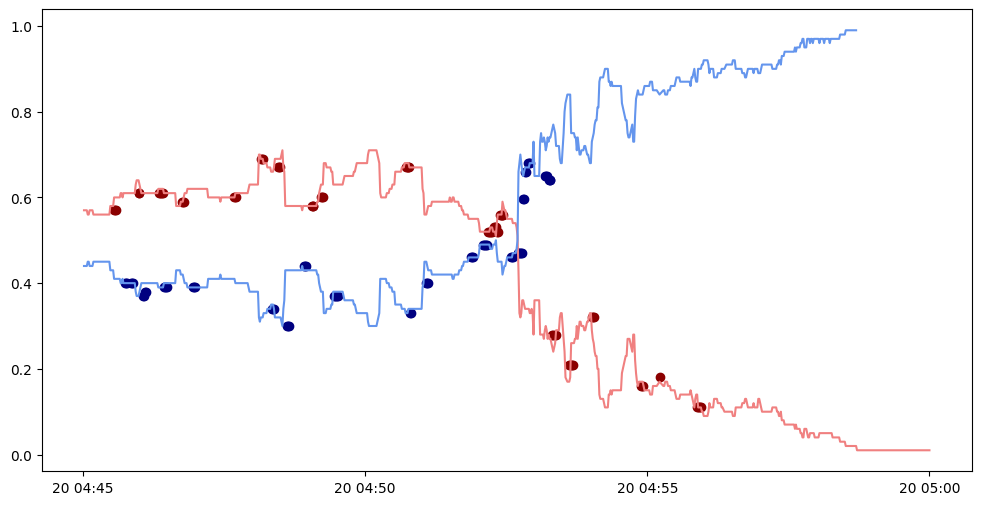

In [856]:
plt.figure(figsize=(12,6))

plt.plot(merged_df["datetime_utc"], merged_df["up_best_ask_price"], c="lightcoral")
plt.scatter(merged_df["datetime_utc"], merged_df["price_Up"], color="darkred")

plt.plot(merged_df["datetime_utc"], merged_df["down_best_ask_price"], c="cornflowerblue")
plt.scatter(merged_df["datetime_utc"], merged_df["price_Down"], color="navy")

Accounting Metrics

In [605]:
Qty_YES = 0
Qty_NO = 0
Cost_YES = 0
Cost_NO = 0

avg_YES = Cost_YES / Qty_YES if Qty_YES > 0 else np.nan
avg_NO  = Cost_NO  / Qty_NO  if Qty_NO > 0 else np.nan

PairCost = avg_YES + avg_NO
LockedProfit = min(Qty_YES, Qty_NO) - (Cost_YES + Cost_NO)


In [743]:
best_prices["yes_imbalance"] = (
    best_prices["yes_best_bid_size"]
    - best_prices["yes_best_ask_size"]
) / (
    best_prices["yes_best_bid_size"]
    + best_prices["yes_best_ask_size"]
)

best_prices["no_imbalance"] = (
    best_prices["no_best_bid_size"]
    - best_prices["no_best_ask_size"]
) / (
    best_prices["no_best_bid_size"]
    + best_prices["no_best_ask_size"]
)

best_prices["pair_best_ask_price"] = best_prices["yes_best_ask_price"] + best_prices["no_best_ask_price"]

best_prices = best_prices.dropna(subset="pair_best_ask_price")
best_prices

,datetime_utc,yes_best_ask_price,yes_best_ask_size,yes_best_bid_price,yes_best_bid_size,no_best_ask_price,no_best_ask_size,no_best_bid_price,no_best_bid_size,arb_gap,yes_imbalance,no_imbalance,pair_best_ask_price
0,2026-01-18 19:45:01.774,0.55,162.68,0.50,6.78,0.50,1.78,0.45,162.68,0.05,-0.919981,0.978353,1.05
1,2026-01-18 19:45:03.006,0.52,61.00,0.50,1.78,0.50,1.78,0.48,61.00,0.02,-0.943294,0.943294,1.02
2,2026-01-18 19:45:04.079,0.52,99.70,0.50,25.78,0.50,25.78,0.48,99.70,0.02,-0.589098,0.589098,1.02
3,2026-01-18 19:45:05.353,0.46,49.50,0.45,183.89,0.55,183.89,0.54,49.50,0.01,0.575817,-0.575817,1.01
4,2026-01-18 19:45:06.431,0.46,123.00,0.45,194.90,0.55,194.90,0.54,123.00,0.01,0.226172,-0.226172,1.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,2026-01-18 19:59:30.842,0.02,1090.46,0.01,3342.22,0.99,3342.22,0.98,1090.46,0.01,0.507991,-0.507991,1.01
743,2026-01-18 19:59:32.021,0.02,1127.40,0.01,2590.81,0.99,2590.81,0.98,1127.40,0.01,0.393579,-0.393579,1.01
744,2026-01-18 19:59:33.240,0.02,1142.27,0.01,131.14,0.99,105.14,0.98,1118.27,0.01,-0.794033,0.828120,1.01
749,2026-01-18 19:59:39.262,0.02,955.53,0.01,135.00,0.99,135.00,0.98,955.53,0.01,-0.752414,0.752414,1.01


Text(0, 0.5, 'Size Imbalance')

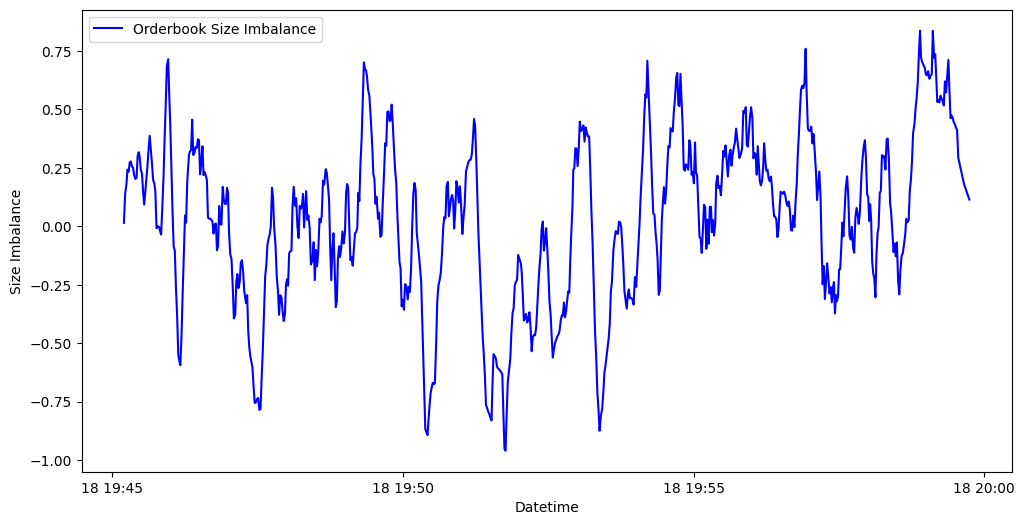

In [748]:
# plt.figure(figsize=(12,6))
fig, ax = plt.subplots(1, 1, figsize=(12,6))
# ax2 = ax.twinx()

# ax.plot(best_prices["datetime_utc"], best_prices["yes_best_ask_price"], c="k", label="Yes Best Ask Price")
# ax.plot(best_prices["datetime_utc"], best_prices["no_best_ask_price"], c="r", label="No Best Ask Price")
# ln1 = ax.plot(best_prices["datetime_utc"], best_prices["arb_size"], c="k", label="Arb Size")
ax.plot(best_prices["datetime_utc"], best_prices["yes_imbalance"].rolling(10).mean(), c="b", label="Orderbook Size Imbalance")

# lns = ln1+ln2
# labs = [l.get_label() for l in lns]
ax.legend()

# ax.set_ylim(-100)
# ax2.set_ylim(-0.04, 0.6)

ax.set_xlabel("Datetime")
ax.set_ylabel("Size Imbalance")
# ax2.set_ylabel("Arb Gap")


### Save Gabagool's trades

In [1236]:
import token
import requests

slug = "btc-updown-15m-1769571900"
url = f"https://gamma-api.polymarket.com/markets/slug/{slug}"

response = requests.get(url)

data = response.json()
tokens = json.loads(data["clobTokenIds"])
tokens

['42510989776860012711802513959807425035193551609364863828979496196621446104983',
 '18995004583785093345291821695592114991844947408559073941018718444417050482869']

In [797]:
import requests

for idx, token in enumerate(tokens):
    url = f"https://clob.polymarket.com/midpoint?token_id={token}"
    response = requests.get(url)
    data = response.json()
    midpoint = float(data["mid"])

    url2 = "https://clob.polymarket.com/spreads"
    payload = [{ "token_id": token }]
    headers = {"Content-Type": "application/json"}
    response2 = requests.post(url2, json=payload, headers=headers)
    data = response2.json()
    spread = float(data[token])

    if idx == 0:
        print(f"Up best ask price: {midpoint+spread/2}")
        print(f"Up best bid price: {midpoint-spread/2}\n")
    else:
        print(f"Down best ask price: {midpoint+spread/2}")
        print(f"Down best bid price: {midpoint-spread/2}\n")


Up best ask price: 0.71
Up best bid price: 0.7

Down best ask price: 0.3
Down best bid price: 0.29



In [1237]:
import requests

url = url = "https://data-api.polymarket.com/trades?limit=100&user=0x6031b6eed1c97e853c6e0f03ad3ce3529351f96d"

response = requests.get(url)

trades_gabagool = response.json()
specific_trades = [trade for trade in trades_gabagool if slug in trade["slug"]]
trades_df = pd.DataFrame(specific_trades)
# trades_df.to_csv(Path.cwd() / "data/external/polymarket/trades/btc-updown-15m-1768765500_gabagool22.csv")
trades_df = trades_df[["timestamp", "side", "outcome", "price", "size"]].sort_values("timestamp")
trades_df["timestamp"] = pd.to_datetime(trades_df["timestamp"], unit="s") - timedelta(hours=5)
trades_df.reset_index(drop=True)

KeyError: "None of [Index(['timestamp', 'side', 'outcome', 'price', 'size'], dtype='object')] are in the [columns]"

In [ ]:
import requests

url = "https://data-api.polymarket.com/trades"

params = {
    "limit": 100000,
    "user": "0x6031b6eed1c97e853c6e0f03ad3ce3529351f96d",
    "side": "BUY",
    # This is the condition ID to help filter trades
    "market": "0x6e0e90f3314aae109c76bb9407b40c044c78426fb1c19e4a9269777b4a804bf8"
}

response = requests.get(url, params=params)
data =response.json()
trades_df = pd.DataFrame(data)
trades_df = trades_df[["timestamp", "side", "outcome", "price", "size"]].sort_values("timestamp")
trades_df["timestamp"] = pd.to_datetime(trades_df["timestamp"], unit="s") - timedelta(hours=5)
# trades_df.to_csv(Path.cwd() / "data/external/polymarket/trades/btc-updown-15m-1768884300_gabagool22.csv")
trades_df.reset_index(drop=True)

,timestamp,side,outcome,price,size
0,2026-01-19 23:45:34,BUY,Up,0.57,19.6997
1,2026-01-19 23:45:34,BUY,Up,0.57,19.6997
2,2026-01-19 23:45:34,BUY,Up,0.57,13.9572
3,2026-01-19 23:45:34,BUY,Up,0.57,14.1700
4,2026-01-19 23:45:46,BUY,Down,0.40,19.7120
...,...,...,...,...,...
102,2026-01-19 23:54:54,BUY,Up,0.16,17.9188
103,2026-01-19 23:54:54,BUY,Up,0.16,15.4599
104,2026-01-19 23:55:12,BUY,Up,0.18,17.9020
105,2026-01-19 23:55:54,BUY,Up,0.11,16.9593


### Backtesting

In [894]:
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple
from itertools import product
import copy


class PolyMarketBacktester:
    def __init__(self, orderbook: pd.DataFrame, capitol: float = 1_000) -> None:
        self.orderbook = orderbook
        self.initial_capitol = capitol
        self.capitol = capitol

        # Position tracking
        self.avg_up_price = 0
        self.avg_down_price = 0
        self.cum_down_size = 0
        self.cum_up_size = 0

        # Trade history
        self.trades = []
        self.orderbook_records = orderbook.to_dict("records")

        # Strategy parameters
        self.imbalance_threshold = -0.6
        self.relative_imbalance_threshold = 0.4
        self.max_position_imbalance = 0.3  # Max difference between up/down positions
        self.max_trade_size_pct = 0.5  # Max % of available liquidity to take
        self.reserve_capitol_pct = 0.2  # Keep 20% in reserve
        self.trade_size = 50  # Base trade size in dollars
        self.fee_rate = 0.005  # 0.5% fee per trade
        self.imbalance_persistence_seconds = (
            3  # Wait N seconds of consecutive imbalance
        )
        self.time_remaining_threshold = (
            60  # Don't trade if less than T seconds remaining
        )
        self.marginal_cost_improvement = 0.002  # Target pair cost improvement

        # State tracking for persistence
        self.imbalance_streak = {"up": [], "down": []}

    @property
    def target_pair_cost_with_fees(self):
        """Target pair cost accounting for fees (must be <= 0.98 for profit)"""
        return 1.0 - (2 * self.fee_rate)  # 0.98 with 1.0% fee on each side

    @property
    def pair_cost(self):
        """Current average cost of holding one UP and one DOWN"""
        return self.avg_up_price + self.avg_down_price

    @property
    def position_imbalance(self):
        """Measure how imbalanced our position is"""
        total = self.cum_up_size + self.cum_down_size
        if total == 0:
            return 0
        return (self.cum_up_size - self.cum_down_size) / total

    @property
    def available_capitol(self):
        """Capitol available for trading (keeping reserve)"""
        return self.capitol * (1 - self.reserve_capitol_pct)

    def calculate_adaptive_trade_size(
        self, side: str, current_price: float, record: Dict
    ) -> float:
        """
        Calculate adaptive trade size using marginal cost targeting
        Target: new_pair_cost <= current_pair_cost - 0.002

        Solve for dq such that new_avg_price satisfies the target
        """
        if side == "up":
            current_size = self.cum_up_size
            current_avg = self.avg_up_price
            other_avg = self.avg_down_price
        else:
            current_size = self.cum_down_size
            current_avg = self.avg_down_price
            other_avg = self.avg_up_price

        # Current pair cost
        current_pair_cost = (
            self.pair_cost
            if self.pair_cost > 0
            else (record["up_best_ask_price"] + record["down_best_ask_price"])
        )

        # Target pair cost (improve by marginal_cost_improvement)
        target_pair_cost = current_pair_cost - self.marginal_cost_improvement

        # If we haven't traded yet, use base trade size
        if current_size == 0:
            return self.trade_size / current_price

        # Solve for dq:
        # new_avg = (current_avg * current_size + current_price * dq) / (current_size + dq)
        # new_pair_cost = new_avg + other_avg = target_pair_cost
        # Therefore: new_avg = target_pair_cost - other_avg

        target_avg = target_pair_cost - other_avg

        # Rearrange to solve for dq:
        # target_avg * (current_size + dq) = current_avg * current_size + current_price * dq
        # target_avg * current_size + target_avg * dq = current_avg * current_size + current_price * dq
        # target_avg * dq - current_price * dq = current_avg * current_size - target_avg * current_size
        # dq * (target_avg - current_price) = current_size * (current_avg - target_avg)
        # dq = current_size * (current_avg - target_avg) / (target_avg - current_price)

        denominator = target_avg - current_price

        # Avoid division by zero or negative trades
        if abs(denominator) < 0.001 or denominator > 0:
            # Fall back to base trade size
            return self.trade_size / current_price

        dq = current_size * (current_avg - target_avg) / denominator

        # Ensure positive trade size
        if dq <= 0:
            return self.trade_size / current_price

        # Cap at reasonable maximum (5x base trade size)
        max_dq = (self.trade_size * 5) / current_price
        return min(dq, max_dq)

    def check_imbalance_persistence(self, record: Dict, side: str) -> bool:
        """
        Check if imbalance has persisted for N consecutive seconds
        """
        timestamp = record["datetime_utc"]

        # Determine if current record satisfies imbalance condition
        if side == "up":
            condition_met = (
                record["up_imbalance"] < self.imbalance_threshold
                or record["relative_imbalance"] < -self.relative_imbalance_threshold
            )
        else:
            condition_met = (
                record["down_imbalance"] < self.imbalance_threshold
                or record["relative_imbalance"] > self.relative_imbalance_threshold
            )

        if condition_met:
            # Add to streak
            self.imbalance_streak[side].append(timestamp)

            # Keep only recent timestamps (within persistence window)
            cutoff = timestamp - pd.Timedelta(
                seconds=self.imbalance_persistence_seconds
            )
            self.imbalance_streak[side] = [
                t for t in self.imbalance_streak[side] if t >= cutoff
            ]

            # Check if we have enough consecutive seconds
            if len(self.imbalance_streak[side]) >= self.imbalance_persistence_seconds:
                return True
        else:
            # Reset streak if condition not met
            self.imbalance_streak[side] = []

        return False

    def get_time_remaining(self, record: Dict) -> float:
        """
        Calculate time remaining in 15-minute window (in seconds)
        Assumes market ends at top of next 15-minute interval
        """
        current_time = record["datetime_utc"]

        # Find next 15-minute boundary
        next_boundary = current_time.ceil("15min")

        # Time remaining in seconds
        time_remaining = (next_boundary - current_time).total_seconds()

        return time_remaining

    def update_avg_price(self, side: str, price: float, size: float):
        """Update volume-weighted average price for a side"""
        if side == "up":
            total_cost = (self.avg_up_price * self.cum_up_size) + (price * size)
            self.cum_up_size += size
            self.avg_up_price = (
                total_cost / self.cum_up_size if self.cum_up_size > 0 else 0
            )
        elif side == "down":
            total_cost = (self.avg_down_price * self.cum_down_size) + (price * size)
            self.cum_down_size += size
            self.avg_down_price = (
                total_cost / self.cum_down_size if self.cum_down_size > 0 else 0
            )

    def execute_trade(
        self,
        record: Dict,
        side: str,
        price: float,
        max_available_size: float,
        adaptive_size: bool = True,
    ):
        """Execute a trade and update positions"""
        # Use adaptive sizing if enabled
        if adaptive_size:
            target_size = self.calculate_adaptive_trade_size(side, price, record)
        else:
            target_size = self.trade_size / price

        # Calculate size we can afford
        size_from_capitol = self.available_capitol / (price * (1 + self.fee_rate))

        # Take max 50% of available liquidity
        size_from_liquidity = max_available_size * self.max_trade_size_pct

        # Use minimum of all constraints
        size = min(size_from_capitol, size_from_liquidity, target_size)

        if size <= 0:
            return False

        # Calculate cost including fees
        cost = size * price * (1 + self.fee_rate)

        # Check if we have enough capitol
        if cost > self.available_capitol:
            return False

        # Execute trade
        self.capitol -= cost
        self.update_avg_price(side, price, size)

        # Record trade
        self.trades.append(
            {
                "timestamp": record["datetime_utc"],
                "side": side,
                "price": price,
                "size": size,
                "cost": cost,
                "fee": size * price * self.fee_rate,
                "capitol_remaining": self.capitol,
                "cum_up_size": self.cum_up_size,
                "cum_down_size": self.cum_down_size,
                "avg_up_price": self.avg_up_price,
                "avg_down_price": self.avg_down_price,
                "pair_cost": self.pair_cost,
            }
        )

        return True

    def should_trade_up(self, record: Dict) -> bool:
        """Determine if we should buy UP"""
        # Don't buy if position is too imbalanced (already too much UP)
        if self.position_imbalance > self.max_position_imbalance:
            return False

        # Check time remaining - don't trade near end
        time_remaining = self.get_time_remaining(record)
        if time_remaining < self.time_remaining_threshold:
            return False

        # Check for imbalance persistence
        has_persistent_imbalance = self.check_imbalance_persistence(record, "up")

        if not has_persistent_imbalance:
            return False

        # Additional signal: pair_best_ask > rolling_pair_best_ask
        rolling_signal = False
        if not pd.isna(record.get("rolling_pair_best_ask")):
            rolling_signal = record["pair_best_ask"] < record["rolling_pair_best_ask"]

        # Buy UP if relative_imbalance is large negative (UP is cheap relative to DOWN)
        if record["relative_imbalance"] < -self.relative_imbalance_threshold:
            return True

        # Buy UP if general imbalance suggests underpriced AND rolling signal confirms
        if record["up_imbalance"] < self.imbalance_threshold: #and rolling_signal:
            return True

        return False

    def should_trade_down(self, record: Dict) -> bool:
        """Determine if we should buy DOWN"""
        # Don't buy if position is too imbalanced (already too much DOWN)
        if self.position_imbalance < -self.max_position_imbalance:
            return False

        # Check time remaining - don't trade near end
        time_remaining = self.get_time_remaining(record)
        if time_remaining < self.time_remaining_threshold:
            return False

        # Check for imbalance persistence
        has_persistent_imbalance = self.check_imbalance_persistence(record, "down")

        if not has_persistent_imbalance:
            return False

        # Additional signal: pair_best_ask > rolling_pair_best_ask
        rolling_signal = False
        if not pd.isna(record.get("rolling_pair_best_ask")):
            rolling_signal = record["pair_best_ask"] < record["rolling_pair_best_ask"]

        # Buy DOWN if relative_imbalance is large positive (DOWN is cheap relative to UP)
        if record["relative_imbalance"] > self.relative_imbalance_threshold:
            return True

        # Buy DOWN if general imbalance suggests underpriced AND rolling signal confirms
        if record["down_imbalance"] < self.imbalance_threshold: #and rolling_signal:
            return True

        return False

    def run_backtest(self, verbose: bool = True):
        """Execute the backtesting strategy"""
        if verbose:
            print(f"Starting backtest with ${self.initial_capitol:.2f}")
            print(f"Total records: {len(self.orderbook_records)}")
            print("=" * 60)

        for i, record in enumerate(self.orderbook_records):
            # Skip if missing critical data
            if pd.isna(record["pair_best_ask"]) or pd.isna(record["arb_gap"]):
                continue

            # Check time remaining - skip if too close to market end
            time_remaining = self.get_time_remaining(record)
            if time_remaining < self.time_remaining_threshold:
                continue

            # Primary strategy: Arbitrage when pair_cost < target (accounting for fees)
            if (
                record["pair_best_ask"] <= self.target_pair_cost_with_fees
                and record["arb_gap"] < -0.01
            ):
                # Buy both UP and DOWN (arbitrage opportunity)
                up_traded = self.execute_trade(
                    record,
                    "up",
                    record["up_best_ask_price"],
                    record["up_best_ask_size"],
                )

                down_traded = self.execute_trade(
                    record,
                    "down",
                    record["down_best_ask_price"],
                    record["down_best_ask_size"],
                )

                if verbose and (up_traded or down_traded):
                    print(f"[{i}] ARB TRADE @ {record['datetime_utc']}")
                    print(
                        f"  Pair cost: {record['pair_best_ask']:.3f}, Gap: {record['arb_gap']:.3f}"
                    )
                    print(f"  Time remaining: {time_remaining:.0f}s")
                    print(
                        f"  Position: UP={self.cum_up_size:.2f}, DOWN={self.cum_down_size:.2f}"
                    )
                    print(f"  Capitol: ${self.capitol:.2f}")

            # Secondary strategy: Trade based on imbalances with persistence
            elif self.should_trade_up(record):
                traded = self.execute_trade(
                    record,
                    "up",
                    record["up_best_ask_price"],
                    record["up_best_ask_size"],
                )

                if verbose and traded:
                    print(f"[{i}] BUY UP @ {record['datetime_utc']}")
                    print(
                        f"  Price: {record['up_best_ask_price']:.3f}, Rel.Imb: {record['relative_imbalance']:.3f}"
                    )
                    print(f"  Time remaining: {time_remaining:.0f}s")
                    print(f"  Position imbalance: {self.position_imbalance:.3f}")

            elif self.should_trade_down(record):
                traded = self.execute_trade(
                    record,
                    "down",
                    record["down_best_ask_price"],
                    record["down_best_ask_size"],
                )

                if verbose and traded:
                    print(f"[{i}] BUY DOWN @ {record['datetime_utc']}")
                    print(
                        f"  Price: {record['down_best_ask_price']:.3f}, Rel.Imb: {record['relative_imbalance']:.3f}"
                    )
                    print(f"  Time remaining: {time_remaining:.0f}s")
                    print(f"  Position imbalance: {self.position_imbalance:.3f}")

        # Calculate final results
        return self.calculate_results(verbose=verbose)

    def calculate_results(self, verbose: bool = True):
        """Calculate and display backtest results"""
        if verbose:
            print("\n" + "=" * 60)
            print("BACKTEST RESULTS")
            print("=" * 60)

        # Position summary
        if verbose:
            print("\nFinal Position:")
            print(f"  UP tokens: {self.cum_up_size:.2f} @ avg {self.avg_up_price:.3f}")
            print(
                f"  DOWN tokens: {self.cum_down_size:.2f} @ avg {self.avg_down_price:.3f}"
            )
            print(f"  Pair cost: {self.pair_cost:.3f}")
            print(f"  Position imbalance: {self.position_imbalance:.3f}")

        # Capitol summary
        if verbose:
            print("\nCapitol:")
            print(f"  Starting: ${self.initial_capitol:.2f}")
            print(f"  Remaining: ${self.capitol:.2f}")
            print(f"  Deployed: ${self.initial_capitol - self.capitol:.2f}")

        # Matched pairs (arb positions that will pay out $1)
        matched_pairs = min(self.cum_up_size, self.cum_down_size)
        unmatched_up = max(0, self.cum_up_size - self.cum_down_size)
        unmatched_down = max(0, self.cum_down_size - self.cum_up_size)

        if verbose:
            print("\nPosition Analysis:")
            print(f"  Matched pairs: {matched_pairs:.2f}")
            print(f"  Unmatched UP: {unmatched_up:.2f}")
            print(f"  Unmatched DOWN: {unmatched_down:.2f}")

        # PnL calculation (assuming market resolves)
        # Matched pairs pay $1 each
        # Unmatched positions pay $1 if they win, $0 if they lose
        # For conservative estimate, assume unmatched positions are worth their avg price
        guaranteed_payout = matched_pairs * 1.0
        unmatched_value_up = unmatched_up * self.avg_up_price
        unmatched_value_down = unmatched_down * self.avg_down_price

        total_value = (
            self.capitol + guaranteed_payout + unmatched_value_up + unmatched_value_down
        )
        pnl = total_value - self.initial_capitol
        roi = (pnl / self.initial_capitol) * 100

        if verbose:
            print("\nP&L (Conservative):")
            print(f"  Guaranteed (pairs): ${guaranteed_payout:.2f}")
            print(
                f"  Unmatched value: ${unmatched_value_up + unmatched_value_down:.2f}"
            )
            print(f"  Total value: ${total_value:.2f}")
            print(f"  P&L: ${pnl:.2f}")
            print(f"  ROI: {roi:.2f}%")

        # Trade statistics
        trades_df = None
        if self.trades:
            trades_df = pd.DataFrame(self.trades)
            if verbose:
                print("\nTrade Statistics:")
                print(f"  Total trades: {len(trades_df)}")
                print(f"  UP trades: {len(trades_df[trades_df['side'] == 'up'])}")
                print(f"  DOWN trades: {len(trades_df[trades_df['side'] == 'down'])}")
                print(f"  Avg trade size: ${trades_df['cost'].mean():.2f}")

        # Return metrics for optimization
        return {
            "trades_df": trades_df,
            "pnl": pnl,
            "roi": roi,
            "pair_cost": self.pair_cost,
            "matched_pairs": matched_pairs,
            "total_trades": len(self.trades),
            "position_imbalance": abs(self.position_imbalance),
            "capitol_remaining": self.capitol,
        }

    def optimize_parameters(
        self,
        imbalance_threshold_range=(-0.8, -0.4, 0.1),
        relative_imbalance_threshold_range=(0.2, 0.6, 0.1),
        max_position_imbalance_range=(0.2, 0.5, 0.1),
        trade_size_range=(25, 100, 25),
        imbalance_persistence_range=(1, 5, 1),
        time_remaining_threshold_range=(30, 120, 30),
        max_iterations=None,
    ):
        """
        Optimize strategy parameters to maximize P&L with pair_cost < 0.98

        Args:
            imbalance_threshold_range: (start, stop, step) for imbalance threshold
            relative_imbalance_threshold_range: (start, stop, step) for relative imbalance
            max_position_imbalance_range: (start, stop, step) for position imbalance limit
            trade_size_range: (start, stop, step) for trade size
            imbalance_persistence_range: (start, stop, step) for persistence in seconds
            time_remaining_threshold_range: (start, stop, step) for min time remaining
            max_iterations: Maximum combinations to test (None = test all)

        Returns:
            DataFrame with all results sorted by P&L
        """
        print("Starting parameter optimization...")
        print("=" * 60)

        # Generate parameter combinations
        imbalance_vals = np.arange(*imbalance_threshold_range)
        rel_imbalance_vals = np.arange(*relative_imbalance_threshold_range)
        position_imb_vals = np.arange(*max_position_imbalance_range)
        trade_size_vals = np.arange(*trade_size_range)
        persistence_vals = np.arange(*imbalance_persistence_range)
        time_remaining_vals = np.arange(*time_remaining_threshold_range)

        param_combinations = list(
            product(
                imbalance_vals,
                rel_imbalance_vals,
                position_imb_vals,
                trade_size_vals,
                persistence_vals,
                time_remaining_vals,
            )
        )

        # Limit iterations if requested
        if max_iterations and len(param_combinations) > max_iterations:
            print(
                f"Sampling {max_iterations} of {len(param_combinations)} combinations"
            )
            np.random.shuffle(param_combinations)
            param_combinations = param_combinations[:max_iterations]
        else:
            print(f"Testing {len(param_combinations)} parameter combinations")

        results = []

        for i, (
            imb_thresh,
            rel_imb_thresh,
            pos_imb,
            trade_sz,
            persistence,
            time_thresh,
        ) in enumerate(param_combinations):
            # Create fresh backtester with new parameters
            bt = PolyMarketBacktester(self.orderbook, self.initial_capitol)
            bt.imbalance_threshold = imb_thresh
            bt.relative_imbalance_threshold = rel_imb_thresh
            bt.max_position_imbalance = pos_imb
            bt.trade_size = trade_sz
            bt.imbalance_persistence_seconds = int(persistence)
            bt.time_remaining_threshold = int(time_thresh)

            # Run backtest silently
            try:
                metrics = bt.run_backtest(verbose=False)

                # Only keep if pair_cost <= 0.98 (constraint with fees)
                if (
                    metrics["pair_cost"] <= bt.target_pair_cost_with_fees
                    or metrics["pair_cost"] == 0
                ):
                    results.append(
                        {
                            "imbalance_threshold": imb_thresh,
                            "relative_imbalance_threshold": rel_imb_thresh,
                            "max_position_imbalance": pos_imb,
                            "trade_size": trade_sz,
                            "imbalance_persistence_seconds": int(persistence),
                            "time_remaining_threshold": int(time_thresh),
                            "pnl": metrics["pnl"],
                            "roi": metrics["roi"],
                            "pair_cost": metrics["pair_cost"],
                            "matched_pairs": metrics["matched_pairs"],
                            "total_trades": metrics["total_trades"],
                            "position_imbalance": metrics["position_imbalance"],
                            "capitol_remaining": metrics["capitol_remaining"],
                        }
                    )

                # Progress update
                if (i + 1) % 50 == 0:
                    print(
                        f"Progress: {i + 1}/{len(param_combinations)} combinations tested"
                    )
                    if results:
                        best = max(results, key=lambda x: x["pnl"])
                        print(
                            f"  Current best P&L: ${best['pnl']:.2f} (ROI: {best['roi']:.2f}%)"
                        )

            except Exception as e:
                # Skip failed combinations
                continue

        # Convert to DataFrame and sort by P&L
        results_df = pd.DataFrame(results)

        if results_df.empty:
            print("\nNo valid parameter combinations found!")
            print("Try relaxing constraints or expanding parameter ranges.")
            return results_df

        results_df = results_df.sort_values("pnl", ascending=False).reset_index(
            drop=True
        )

        # Filter for positive P&L
        positive_pnl = results_df[results_df["pnl"] > 0]

        print("\n" + "=" * 60)
        print("OPTIMIZATION RESULTS")
        print("=" * 60)
        print(f"\nTotal valid combinations: {len(results_df)}")
        print(f"Combinations with positive P&L: {len(positive_pnl)}")

        if not positive_pnl.empty:
            best = positive_pnl.iloc[0]
            print("\nBEST PARAMETERS (Highest P&L):")
            print(f"  Imbalance threshold: {best['imbalance_threshold']:.2f}")
            print(
                f"  Relative imbalance threshold: {best['relative_imbalance_threshold']:.2f}"
            )
            print(f"  Max position imbalance: {best['max_position_imbalance']:.2f}")
            print(f"  Trade size: ${best['trade_size']:.2f}")
            print(
                f"  Imbalance persistence: {int(best['imbalance_persistence_seconds'])}s"
            )
            print(
                f"  Time remaining threshold: {int(best['time_remaining_threshold'])}s"
            )
            print("\n  Results:")
            print(f"    P&L: ${best['pnl']:.2f}")
            print(f"    ROI: {best['roi']:.2f}%")
            print(f"    Pair cost: {best['pair_cost']:.3f}")
            print(f"    Matched pairs: {best['matched_pairs']:.2f}")
            print(f"    Total trades: {int(best['total_trades'])}")

            # Show top 5
            print("\nTop 5 Parameter Sets:")
            print(
                positive_pnl[
                    [
                        "pnl",
                        "roi",
                        "pair_cost",
                        "trade_size",
                        "imbalance_persistence_seconds",
                        "time_remaining_threshold",
                    ]
                ].head()
            )
        else:
            print("\nNo combinations achieved positive P&L.")
            print("Best attempt:")
            best = results_df.iloc[0]
            print(f"  P&L: ${best['pnl']:.2f}")
            print(f"  Pair cost: {best['pair_cost']:.3f}")

        return results_df

    def apply_best_parameters(self, results_df: pd.DataFrame):
        """Apply the best parameters from optimization results"""
        if results_df.empty:
            print("No results to apply!")
            return

        # Get best positive P&L result
        positive_pnl = results_df[results_df["pnl"] > 0]
        if positive_pnl.empty:
            print("No positive P&L results found!")
            return

        best = positive_pnl.iloc[0]

        self.imbalance_threshold = best["imbalance_threshold"]
        self.relative_imbalance_threshold = best["relative_imbalance_threshold"]
        self.max_position_imbalance = best["max_position_imbalance"]
        self.trade_size = best["trade_size"]
        self.imbalance_persistence_seconds = int(best["imbalance_persistence_seconds"])
        self.time_remaining_threshold = int(best["time_remaining_threshold"])

        print("Applied best parameters:")
        print(f"  Imbalance threshold: {self.imbalance_threshold:.2f}")
        print(
            f"  Relative imbalance threshold: {self.relative_imbalance_threshold:.2f}"
        )
        print(f"  Max position imbalance: {self.max_position_imbalance:.2f}")
        print(f"  Trade size: ${self.trade_size:.2f}")
        print(f"  Imbalance persistence: {self.imbalance_persistence_seconds}s")
        print(f"  Time remaining threshold: {self.time_remaining_threshold}s")


# Example usage
if __name__ == "__main__":
    # Load your orderbook data
    # df_orderbook = pd.read_csv('your_orderbook.csv')

    # Method 1: Run with default parameters
    backtester = PolyMarketBacktester(orderbook=best_prices, capitol=1000)
    results = backtester.run_backtest(verbose=False)

    # Method 2: Optimize parameters
    backtester = PolyMarketBacktester(orderbook=best_prices, capitol=1000)
    optimization_results = backtester.optimize_parameters(
        imbalance_threshold_range=(-0.8, -0.2, 0.1),
        relative_imbalance_threshold_range=(0.2, 0.8, 0.1),
        max_position_imbalance_range=(0.1, 0.5, 0.1),
        trade_size_range=(25, 100, 25),
        max_iterations=500,  # Limit for speed
    )

    # Save optimization results
    optimization_results.to_csv("optimization_results.csv", index=False)

    # Apply best parameters and run final backtest
    backtester.apply_best_parameters(optimization_results)
    final_results = backtester.run_backtest(verbose=False)

    # if final_results["trades_df"] is not None:
    #     final_results["trades_df"].to_csv("final_backtest_trades.csv", index=False)

Starting parameter optimization...
Sampling 500 of 7056 combinations
Progress: 50/500 combinations tested
Progress: 100/500 combinations tested
Progress: 150/500 combinations tested
Progress: 200/500 combinations tested
Progress: 250/500 combinations tested
Progress: 300/500 combinations tested
Progress: 350/500 combinations tested
Progress: 400/500 combinations tested
Progress: 450/500 combinations tested
Progress: 500/500 combinations tested

No valid parameter combinations found!
Try relaxing constraints or expanding parameter ranges.
No results to apply!


In [ ]:
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple
from itertools import product
import copy


class PolyMarketBacktester:
    def __init__(self, orderbook: pd.DataFrame, capitol: float = 1_000) -> None:
        self.orderbook = orderbook
        self.initial_capitol = capitol
        self.capitol = capitol

        # Position tracking
        self.avg_up_price = 0
        self.avg_down_price = 0
        self.cum_down_size = 0
        self.cum_up_size = 0
        self.last_recycled_pairs = 0  # Track recycled capital

        # Trade history
        self.trades = []
        self.pending_orders = []  # Track limit orders
        self.orderbook_records = orderbook.to_dict("records")

        # Strategy parameters
        self.imbalance_threshold = -0.6
        self.relative_imbalance_threshold = 0.4
        self.max_position_imbalance = 0.3  # Max difference between up/down positions
        self.max_trade_size_pct = 0.5  # Max % of available liquidity to take
        self.reserve_capitol_pct = 0.2  # Keep 20% in reserve
        self.trade_size = 50  # Base trade size in dollars
        self.fee_rate = 0.005  # 0.5% fee per trade
        self.imbalance_persistence_seconds = (
            3  # Wait N seconds of consecutive imbalance
        )
        self.time_remaining_threshold = (
            60  # Don't trade if less than T seconds remaining
        )
        self.marginal_cost_improvement = 0.002  # Target pair cost improvement

        # State tracking for persistence
        self.imbalance_streak = {"up": [], "down": []}

    @property
    def target_pair_cost_with_fees(self):
        """Target pair cost accounting for fees (must be <= 0.99 for profit)"""
        return 1.0 - (2 * self.fee_rate)  # 0.99 with 0.5% fee on each side

    @property
    def pair_cost(self):
        """Current average cost of holding one UP and one DOWN"""
        return self.avg_up_price + self.avg_down_price

    @property
    def position_imbalance(self):
        """Measure how imbalanced our position is"""
        total = self.cum_up_size + self.cum_down_size
        if total == 0:
            return 0
        return (self.cum_up_size - self.cum_down_size) / total

    @property
    def available_capitol(self):
        """Capitol available for trading (keeping reserve)"""
        return self.capitol * (1 - self.reserve_capitol_pct)

    def recycle_matched_pairs(self):
        """
        Release capital from matched UP/DOWN pairs back to available capital
        When we have matched pairs, they're guaranteed $1 payout, so we can
        recycle that capital immediately
        """
        current_matched_pairs = min(self.cum_up_size, self.cum_down_size)

        # Only recycle newly formed pairs
        newly_matched = current_matched_pairs - self.last_recycled_pairs

        if newly_matched > 0:
            # Each matched pair is worth $1, recycle that capital
            recycled_amount = newly_matched * 1.0
            # self.capitol += recycled_amount
            self.last_recycled_pairs = current_matched_pairs

            return recycled_amount

        return 0

    def check_pending_orders(self, record: Dict):
        """
        Check if any pending limit orders should be filled
        Fill if best_ask crosses our bid limit price
        """
        filled_orders = []

        for order in self.pending_orders:
            side = order['side']
            limit_price = order['limit_price']

            # Check if ask price crosses our limit bid price
            if side == 'up':
                current_ask = record['up_best_ask_price']
                available_size = record['up_best_ask_size']
                if current_ask <= limit_price:
                    # Fill at our limit price
                    filled = self.execute_fill(order, record, available_size)
                    if filled:
                        filled_orders.append(order)

            elif side == 'down':
                current_ask = record['down_best_ask_price']
                available_size = record['down_best_ask_size']
                if current_ask <= limit_price:
                    # Fill at our limit price
                    filled = self.execute_fill(order, record, available_size)
                    if filled:
                        filled_orders.append(order)

        # Remove filled orders
        for order in filled_orders:
            self.pending_orders.remove(order)

        return len(filled_orders) > 0

    def execute_fill(self, order: Dict, record: Dict, max_available_size: float):
        """Execute a pending limit order fill"""
        side = order['side']
        limit_price = order['limit_price']
        target_size = order['size']

        # Adjust size based on available liquidity
        size_from_liquidity = max_available_size * self.max_trade_size_pct
        size = min(target_size, size_from_liquidity)

        if size <= 0:
            return False

        # Calculate cost including fees at our limit price
        cost = size * limit_price * (1 + self.fee_rate)

        # Check if we still have enough capital (might have changed)
        if cost > self.available_capitol:
            return False

        # Execute trade
        self.capitol -= cost
        self.update_avg_price(side, limit_price, size)

        # Record trade
        self.trades.append({
            'timestamp': record['datetime_utc'],
            'side': side,
            'price': limit_price,
            'size': size,
            'cost': cost,
            'fee': size * limit_price * self.fee_rate,
            'capitol_remaining': self.capitol,
            'cum_up_size': self.cum_up_size,
            'cum_down_size': self.cum_down_size,
            'avg_up_price': self.avg_up_price,
            'avg_down_price': self.avg_down_price,
            'pair_cost': self.pair_cost,
            'order_type': 'limit_fill'
        })

        return True

    def calculate_adaptive_trade_size(
        self, side: str, current_price: float, record: Dict
    ) -> float:
        """
        Calculate adaptive trade size using marginal cost targeting
        Target: new_pair_cost <= current_pair_cost - 0.002

        Solve for dq such that new_avg_price satisfies the target
        """
        if side == "up":
            current_size = self.cum_up_size
            current_avg = self.avg_up_price
            other_avg = self.avg_down_price
        else:
            current_size = self.cum_down_size
            current_avg = self.avg_down_price
            other_avg = self.avg_up_price

        # Current pair cost
        current_pair_cost = (
            self.pair_cost
            if self.pair_cost > 0
            else (record["up_best_bid_price"] + record["down_best_bid_price"])
        )

        # Target pair cost (improve by marginal_cost_improvement)
        target_pair_cost = current_pair_cost - self.marginal_cost_improvement

        # If we haven't traded yet, use base trade size
        if current_size == 0:
            return self.trade_size / current_price

        # Solve for dq:
        # new_avg = (current_avg * current_size + current_price * dq) / (current_size + dq)
        # new_pair_cost = new_avg + other_avg = target_pair_cost
        # Therefore: new_avg = target_pair_cost - other_avg

        target_avg = target_pair_cost - other_avg

        # Rearrange to solve for dq:
        # target_avg * (current_size + dq) = current_avg * current_size + current_price * dq
        # target_avg * current_size + target_avg * dq = current_avg * current_size + current_price * dq
        # target_avg * dq - current_price * dq = current_avg * current_size - target_avg * current_size
        # dq * (target_avg - current_price) = current_size * (current_avg - target_avg)
        # dq = current_size * (current_avg - target_avg) / (target_avg - current_price)

        denominator = target_avg - current_price

        # Avoid division by zero or negative trades
        if abs(denominator) < 0.001 or denominator > 0:
            # Fall back to base trade size
            return self.trade_size / current_price

        dq = current_size * (current_avg - target_avg) / denominator

        # Ensure positive trade size
        if dq <= 0:
            return self.trade_size / current_price

        # Cap at reasonable maximum (10x base trade size)
        max_dq = (self.trade_size * 10) / current_price
        return min(dq, max_dq)

    def check_imbalance_persistence(self, record: Dict, side: str) -> bool:
        """
        Check if imbalance has persisted for N consecutive seconds
        """
        timestamp = record["datetime_utc"]

        # Determine if current record satisfies imbalance condition
        if side == "up":
            condition_met = (
                record["up_imbalance"] < self.imbalance_threshold
                or record["relative_imbalance"] < -self.relative_imbalance_threshold
            )
        else:
            condition_met = (
                record["down_imbalance"] < self.imbalance_threshold
                or record["relative_imbalance"] > self.relative_imbalance_threshold
            )

        if condition_met:
            # Add to streak
            self.imbalance_streak[side].append(timestamp)

            # Keep only recent timestamps (within persistence window)
            cutoff = timestamp - pd.Timedelta(
                seconds=self.imbalance_persistence_seconds
            )
            self.imbalance_streak[side] = [
                t for t in self.imbalance_streak[side] if t >= cutoff
            ]

            # Check if we have enough consecutive seconds
            if len(self.imbalance_streak[side]) >= self.imbalance_persistence_seconds:
                return True
        else:
            # Reset streak if condition not met
            self.imbalance_streak[side] = []

        return False

    def get_time_remaining(self, record: Dict) -> float:
        """
        Calculate time remaining in 15-minute window (in seconds)
        Assumes market ends at top of next 15-minute interval
        """
        current_time = record["datetime_utc"]

        # Find next 15-minute boundary
        next_boundary = current_time.ceil("15min")

        # Time remaining in seconds
        time_remaining = (next_boundary - current_time).total_seconds()

        return time_remaining

    def update_avg_price(self, side: str, price: float, size: float):
        """Update volume-weighted average price for a side"""
        if side == "up":
            total_cost = (self.avg_up_price * self.cum_up_size) + (price * size)
            self.cum_up_size += size
            self.avg_up_price = (
                total_cost / self.cum_up_size if self.cum_up_size > 0 else 0
            )
        elif side == "down":
            total_cost = (self.avg_down_price * self.cum_down_size) + (price * size)
            self.cum_down_size += size
            self.avg_down_price = (
                total_cost / self.cum_down_size if self.cum_down_size > 0 else 0
            )

    def place_limit_order(
        self,
        record: Dict,
        side: str,
        bid_price: float,
        max_available_size: float,
        adaptive_size: bool = True,
    ):
        """
        Place a limit order at the best bid price
        Order will be filled if ask price crosses this level
        """
        # Use adaptive sizing if enabled
        if adaptive_size:
            target_size = self.calculate_adaptive_trade_size(side, bid_price, record)
        else:
            target_size = self.trade_size / bid_price

        # Calculate size we can afford
        size_from_capitol = self.available_capitol / (bid_price * (1 + self.fee_rate))

        # Take max 50% of available liquidity
        size_from_liquidity = max_available_size * self.max_trade_size_pct

        # Use minimum of all constraints
        size = min(size_from_capitol, size_from_liquidity, target_size)

        if size <= 0:
            return False

        # Create pending order
        order = {
            'timestamp': record['datetime_utc'],
            'side': side,
            'limit_price': bid_price,
            'size': size,
        }

        self.pending_orders.append(order)
        return True

    def should_trade_up(self, record: Dict) -> bool:
        """Determine if we should buy UP"""
        # Don't buy if position is too imbalanced (already too much UP)
        if self.position_imbalance > self.max_position_imbalance:
            return False

        # Check time remaining - don't trade near end
        time_remaining = self.get_time_remaining(record)
        if time_remaining < self.time_remaining_threshold:
            return False

        # Check for imbalance persistence
        has_persistent_imbalance = self.check_imbalance_persistence(record, "up")

        if not has_persistent_imbalance:
            return False

        # Buy UP if relative_imbalance is large negative (UP is cheap relative to DOWN)
        if record["relative_imbalance"] < -self.relative_imbalance_threshold:
            return True

        # Buy UP if general imbalance suggests underpriced
        if record["up_imbalance"] < self.imbalance_threshold:
            return True

        return False

    def should_trade_down(self, record: Dict) -> bool:
        """Determine if we should buy DOWN"""
        # Don't buy if position is too imbalanced (already too much DOWN)
        if self.position_imbalance < -self.max_position_imbalance:
            return False

        # Check time remaining - don't trade near end
        time_remaining = self.get_time_remaining(record)
        if time_remaining < self.time_remaining_threshold:
            return False

        # Check for imbalance persistence
        has_persistent_imbalance = self.check_imbalance_persistence(record, "down")

        if not has_persistent_imbalance:
            return False

        # Buy DOWN if relative_imbalance is large positive (DOWN is cheap relative to UP)
        if record["relative_imbalance"] > self.relative_imbalance_threshold:
            return True

        # Buy DOWN if general imbalance suggests underpriced
        if record["down_imbalance"] < self.imbalance_threshold:
            return True

        return False

    def run_backtest(self, verbose: bool = True):
        """Execute the backtesting strategy"""
        if verbose:
            print(f"Starting backtest with ${self.initial_capitol:.2f}")
            print(f"Total records: {len(self.orderbook_records)}")
            print("=" * 60)

        for i, record in enumerate(self.orderbook_records):
            # Skip if missing critical data
            if pd.isna(record["pair_best_ask"]) or pd.isna(record["arb_gap"]):
                continue

            # Check and fill any pending limit orders first
            self.check_pending_orders(record)

            # Recycle capital from matched pairs
            recycled = self.recycle_matched_pairs()
            if verbose and recycled > 0:
                print(f"  💰 Recycled ${recycled:.2f} from {self.last_recycled_pairs:.2f} matched pairs")

            # Check time remaining - skip if too close to market end
            time_remaining = self.get_time_remaining(record)
            if time_remaining < self.time_remaining_threshold:
                continue

            # Primary strategy: Arbitrage when pair_cost < target (accounting for fees)
            if (
                record["pair_best_ask"] <= self.target_pair_cost_with_fees
                and record["arb_gap"] < -0.01
            ):
                # Place limit orders at bid prices for both UP and DOWN
                up_traded = self.place_limit_order(
                    record,
                    "up",
                    record["up_best_bid_price"],
                    record["up_best_bid_size"],
                )

                down_traded = self.place_limit_order(
                    record,
                    "down",
                    record["down_best_bid_price"],
                    record["down_best_bid_size"],
                )

                if verbose and (up_traded or down_traded):
                    print(f"[{i}] ARB LIMIT ORDER @ {record['datetime_utc']}")
                    print(
                        f"  Pair cost: {record['pair_best_ask']:.3f}, Gap: {record['arb_gap']:.3f}"
                    )
                    print(f"  UP bid: {record['up_best_bid_price']:.3f}, DOWN bid: {record['down_best_bid_price']:.3f}")
                    print(f"  Time remaining: {time_remaining:.0f}s")
                    print(
                        f"  Position: UP={self.cum_up_size:.2f}, DOWN={self.cum_down_size:.2f}"
                    )
                    print(f"  Capitol: ${self.capitol:.2f}")

            # Secondary strategy: Trade based on imbalances with persistence
            elif self.should_trade_up(record):
                traded = self.place_limit_order(
                    record,
                    "up",
                    record["up_best_bid_price"],
                    record["up_best_bid_size"],
                )

                if verbose and traded:
                    print(f"[{i}] BUY UP LIMIT @ {record['datetime_utc']}")
                    print(
                        f"  Bid price: {record['up_best_bid_price']:.3f}, Rel.Imb: {record['relative_imbalance']:.3f}"
                    )
                    print(f"  Time remaining: {time_remaining:.0f}s")
                    print(f"  Position imbalance: {self.position_imbalance:.3f}")

            elif self.should_trade_down(record):
                traded = self.place_limit_order(
                    record,
                    "down",
                    record["down_best_bid_price"],
                    record["down_best_bid_size"],
                )

                if verbose and traded:
                    print(f"[{i}] BUY DOWN LIMIT @ {record['datetime_utc']}")
                    print(
                        f"  Bid price: {record['down_best_bid_price']:.3f}, Rel.Imb: {record['relative_imbalance']:.3f}"
                    )
                    print(f"  Time remaining: {time_remaining:.0f}s")
                    print(f"  Position imbalance: {self.position_imbalance:.3f}")

        # Calculate final results
        return self.calculate_results(verbose=verbose)

    def calculate_results(self, verbose: bool = True):
        """Calculate and display backtest results"""
        if verbose:
            print("\n" + "=" * 60)
            print("BACKTEST RESULTS")
            print("=" * 60)

        # Position summary
        if verbose:
            print("\nFinal Position:")
            print(f"  UP tokens: {self.cum_up_size:.2f} @ avg {self.avg_up_price:.3f}")
            print(
                f"  DOWN tokens: {self.cum_down_size:.2f} @ avg {self.avg_down_price:.3f}"
            )
            print(f"  Pair cost: {self.pair_cost:.3f}")
            print(f"  Position imbalance: {self.position_imbalance:.3f}")
            print(f"  Pending orders: {len(self.pending_orders)}")

        # Capitol summary
        if verbose:
            print("\nCapitol:")
            print(f"  Starting: ${self.initial_capitol:.2f}")
            print(f"  Remaining: ${self.capitol:.2f}")
            print(f"  Deployed: ${self.initial_capitol - self.capitol:.2f}")
            print(f"  Recycled from pairs: ${self.last_recycled_pairs * 1.0:.2f}")

        # Matched pairs (arb positions that will pay out $1)
        matched_pairs = min(self.cum_up_size, self.cum_down_size)
        unmatched_up = max(0, self.cum_up_size - self.cum_down_size)
        unmatched_down = max(0, self.cum_down_size - self.cum_up_size)

        if verbose:
            print("\nPosition Analysis:")
            print(f"  Matched pairs: {matched_pairs:.2f}")
            print(f"  Unmatched UP: {unmatched_up:.2f}")
            print(f"  Unmatched DOWN: {unmatched_down:.2f}")

        # PnL calculation (assuming market resolves)
        # Matched pairs pay $1 each
        # Unmatched positions pay $1 if they win, $0 if they lose
        # For conservative estimate, assume unmatched positions are worth their avg price
        guaranteed_payout = matched_pairs * 1.0
        unmatched_value_up = unmatched_up * self.avg_up_price
        unmatched_value_down = unmatched_down * self.avg_down_price

        total_value = (
            self.capitol + guaranteed_payout + unmatched_value_up + unmatched_value_down
        )
        pnl = total_value - self.initial_capitol
        roi = (pnl / self.initial_capitol) * 100

        if verbose:
            print("\nP&L (Conservative):")
            print(f"  Guaranteed (pairs): ${guaranteed_payout:.2f}")
            print(
                f"  Unmatched value: ${unmatched_value_up + unmatched_value_down:.2f}"
            )
            print(f"  Total value: ${total_value:.2f}")
            print(f"  P&L: ${pnl:.2f}")
            print(f"  ROI: {roi:.2f}%")

        # Trade statistics
        trades_df = None
        if self.trades:
            trades_df = pd.DataFrame(self.trades)
            if verbose:
                print("\nTrade Statistics:")
                print(f"  Total trades: {len(trades_df)}")
                print(f"  UP trades: {len(trades_df[trades_df['side'] == 'up'])}")
                print(f"  DOWN trades: {len(trades_df[trades_df['side'] == 'down'])}")
                print(f"  Avg trade size: ${trades_df['cost'].mean():.2f}")
                limit_fills = len(trades_df[trades_df.get('order_type') == 'limit_fill'])
                print(f"  Limit order fills: {limit_fills}")

        # Return metrics for optimization
        return {
            "trades_df": trades_df,
            "pnl": pnl,
            "roi": roi,
            "pair_cost": self.pair_cost,
            "matched_pairs": matched_pairs,
            "total_trades": len(self.trades),
            "position_imbalance": abs(self.position_imbalance),
            "capitol_remaining": self.capitol,
        }

    def optimize_parameters(
        self,
        imbalance_threshold_range=(-0.8, -0.4, 0.1),
        relative_imbalance_threshold_range=(0.2, 0.6, 0.1),
        max_position_imbalance_range=(0.2, 0.5, 0.1),
        trade_size_range=(25, 100, 25),
        imbalance_persistence_range=(1, 5, 1),
        time_remaining_threshold_range=(30, 120, 30),
        max_iterations=None,
    ):
        """
        Optimize strategy parameters to maximize P&L with pair_cost < 0.99

        Args:
            imbalance_threshold_range: (start, stop, step) for imbalance threshold
            relative_imbalance_threshold_range: (start, stop, step) for relative imbalance
            max_position_imbalance_range: (start, stop, step) for position imbalance limit
            trade_size_range: (start, stop, step) for trade size
            imbalance_persistence_range: (start, stop, step) for persistence in seconds
            time_remaining_threshold_range: (start, stop, step) for min time remaining
            max_iterations: Maximum combinations to test (None = test all)

        Returns:
            DataFrame with all results sorted by P&L
        """
        print("Starting parameter optimization...")
        print("=" * 60)

        # Generate parameter combinations
        imbalance_vals = np.arange(*imbalance_threshold_range)
        rel_imbalance_vals = np.arange(*relative_imbalance_threshold_range)
        position_imb_vals = np.arange(*max_position_imbalance_range)
        trade_size_vals = np.arange(*trade_size_range)
        persistence_vals = np.arange(*imbalance_persistence_range)
        time_remaining_vals = np.arange(*time_remaining_threshold_range)

        param_combinations = list(
            product(
                imbalance_vals,
                rel_imbalance_vals,
                position_imb_vals,
                trade_size_vals,
                persistence_vals,
                time_remaining_vals,
            )
        )

        # Limit iterations if requested
        if max_iterations and len(param_combinations) > max_iterations:
            print(
                f"Sampling {max_iterations} of {len(param_combinations)} combinations"
            )
            np.random.shuffle(param_combinations)
            param_combinations = param_combinations[:max_iterations]
        else:
            print(f"Testing {len(param_combinations)} parameter combinations")

        results = []

        for i, (
            imb_thresh,
            rel_imb_thresh,
            pos_imb,
            trade_sz,
            persistence,
            time_thresh,
        ) in enumerate(param_combinations):
            # Create fresh backtester with new parameters
            bt = PolyMarketBacktester(self.orderbook, self.initial_capitol)
            bt.imbalance_threshold = imb_thresh
            bt.relative_imbalance_threshold = rel_imb_thresh
            bt.max_position_imbalance = pos_imb
            bt.trade_size = trade_sz
            bt.imbalance_persistence_seconds = int(persistence)
            bt.time_remaining_threshold = int(time_thresh)

            # Run backtest silently
            try:
                metrics = bt.run_backtest(verbose=False)

                # Only keep if pair_cost <= 0.99 (constraint with fees)
                if (
                    metrics["pair_cost"] <= bt.target_pair_cost_with_fees
                    or metrics["pair_cost"] == 0
                ):
                    results.append(
                        {
                            "imbalance_threshold": imb_thresh,
                            "relative_imbalance_threshold": rel_imb_thresh,
                            "max_position_imbalance": pos_imb,
                            "trade_size": trade_sz,
                            "imbalance_persistence_seconds": int(persistence),
                            "time_remaining_threshold": int(time_thresh),
                            "pnl": metrics["pnl"],
                            "roi": metrics["roi"],
                            "pair_cost": metrics["pair_cost"],
                            "matched_pairs": metrics["matched_pairs"],
                            "total_trades": metrics["total_trades"],
                            "position_imbalance": metrics["position_imbalance"],
                            "capitol_remaining": metrics["capitol_remaining"],
                        }
                    )

                # Progress update
                if (i + 1) % 50 == 0:
                    print(
                        f"Progress: {i + 1}/{len(param_combinations)} combinations tested"
                    )
                    if results:
                        best = max(results, key=lambda x: x["pnl"])
                        print(
                            f"  Current best P&L: ${best['pnl']:.2f} (ROI: {best['roi']:.2f}%)"
                        )

            except Exception as e:
                # Skip failed combinations
                continue

        # Convert to DataFrame and sort by P&L
        results_df = pd.DataFrame(results)

        if results_df.empty:
            print("\nNo valid parameter combinations found!")
            print("Try relaxing constraints or expanding parameter ranges.")
            return results_df

        results_df = results_df.sort_values("pnl", ascending=False).reset_index(
            drop=True
        )

        # Filter for positive P&L
        positive_pnl = results_df[results_df["pnl"] > 0]

        print("\n" + "=" * 60)
        print("OPTIMIZATION RESULTS")
        print("=" * 60)
        print(f"\nTotal valid combinations: {len(results_df)}")
        print(f"Combinations with positive P&L: {len(positive_pnl)}")

        if not positive_pnl.empty:
            best = positive_pnl.iloc[0]
            print("\nBEST PARAMETERS (Highest P&L):")
            print(f"  Imbalance threshold: {best['imbalance_threshold']:.2f}")
            print(
                f"  Relative imbalance threshold: {best['relative_imbalance_threshold']:.2f}"
            )
            print(f"  Max position imbalance: {best['max_position_imbalance']:.2f}")
            print(f"  Trade size: ${best['trade_size']:.2f}")
            print(
                f"  Imbalance persistence: {int(best['imbalance_persistence_seconds'])}s"
            )
            print(
                f"  Time remaining threshold: {int(best['time_remaining_threshold'])}s"
            )
            print("\n  Results:")
            print(f"    P&L: ${best['pnl']:.2f}")
            print(f"    ROI: {best['roi']:.2f}%")
            print(f"    Pair cost: {best['pair_cost']:.3f}")
            print(f"    Matched pairs: {best['matched_pairs']:.2f}")
            print(f"    Total trades: {int(best['total_trades'])}")

            # Show top 5
            print("\nTop 5 Parameter Sets:")
            print(
                positive_pnl[
                    [
                        "pnl",
                        "roi",
                        "pair_cost",
                        "trade_size",
                        "imbalance_persistence_seconds",
                        "time_remaining_threshold",
                    ]
                ].head()
            )
        else:
            print("\nNo combinations achieved positive P&L.")
            print("Best attempt:")
            best = results_df.iloc[0]
            print(f"  P&L: ${best['pnl']:.2f}")
            print(f"  Pair cost: {best['pair_cost']:.3f}")

        return results_df

    def apply_best_parameters(self, results_df: pd.DataFrame):
        """Apply the best parameters from optimization results"""
        if results_df.empty:
            print("No results to apply!")
            return

        # Get best positive P&L result
        positive_pnl = results_df[results_df["pnl"] > 0]
        if positive_pnl.empty:
            print("No positive P&L results found!")
            return

        best = positive_pnl.iloc[0]

        self.imbalance_threshold = best["imbalance_threshold"]
        self.relative_imbalance_threshold = best["relative_imbalance_threshold"]
        self.max_position_imbalance = best["max_position_imbalance"]
        self.trade_size = best["trade_size"]
        self.imbalance_persistence_seconds = int(best["imbalance_persistence_seconds"])
        self.time_remaining_threshold = int(best["time_remaining_threshold"])

        print("Applied best parameters:")
        print(f"  Imbalance threshold: {self.imbalance_threshold:.2f}")
        print(
            f"  Relative imbalance threshold: {self.relative_imbalance_threshold:.2f}"
        )
        print(f"  Max position imbalance: {self.max_position_imbalance:.2f}")
        print(f"  Trade size: ${self.trade_size:.2f}")
        print(f"  Imbalance persistence: {self.imbalance_persistence_seconds}s")
        print(f"  Time remaining threshold: {self.time_remaining_threshold}s")


### Current Strategy

**Up Direction**

- If position imbalance is greater than max position imbalance DO NOT BUY
- if the time remaining is less than the time remaining threshold DO NOT BUY
- If the relative imbalance or directional imbalance is not below there respective thresholds DO NOT BUY
- If the relative imbalance is less than the relative imbalance threshold then BUY (up is cheap compared to down)
- If the imbalance is less than the imbalance threshold then BUY (suggests up is underpriced)

**Down Direction**

- If position imbalance is greater than max position imbalance DO NOT BUY
- if the time remaining is less than the time remaining threshold DO NOT BUY
- If the relative imbalance or directional imbalance is not below there respective thresholds DO NOT BUY
- If the relative imbalance is greater than the relative imbalance threshold then BUY (down is cheap compared to up)
- If the imbalance is less than the imbalance threshold then BUY (suggests down is underpriced)

---

### Modifying Strategy

**Up Direction**

- If the pair best ask price is greater than the pair best ask threshold DO NOT BUY
- If the spread is above the spread threshold DO NOT BUY (modify this to relative spread possibly)
- Liquidity filter, if the depth liquidity is too thin avoid trades since price may jump (limit orders can also solve this)
- If position imbalance is greater than max position imbalance DO NOT BUY (up and down total sizes are significantly different)
- if the time remaining is less than the time remaining threshold DO NOT BUY

- Filter out with depth imbalance first and if that is greater than a threshold then DO NOT BUY
  - Depth imbalance will suggest whether there is more potential upward price movement (buy-heavy imbalance) or downward price movement (sell-heavy imbalance)
- Filter out trades with microprice - midprice compared to some threshold
  - If greater than 0, indicates upward pressure, more size on bid likely to move up
  - If less than 0, indicates downward pressure, more size on ask likely to go down
  - Use this as a filter not an entry signaler, if it is delta_u << 0 avoid buying
  - Normalize it by spread so (microprice - mid)/spread and use an assymttric threshhold mp_signal < -0.25 avoid buying, mp_signal > 0.25 avoid selling
  - Can combine this with depth_imbalance as toxic = mp_signal \* depth_imbalance > 0.15, if toxic is true DO NOT BUY
- Check relative_imbalance + pair_best_ask as a signal to use as well to determine if the arb is cheap
- If the relative imbalance or directional imbalance is not below there respective thresholds DO NOT BUY
- If the relative imbalance is less than the relative imbalance threshold then BUY (up is cheap compared to down)
- If the directional imbalance is less than the directional imbalance threshold then BUY (suggests up is underpriced)

**Down Direction**

- If the pair best ask price is greater than the pair best ask threshold DO NOT BUY
- If the spread is above the spread threshold DO NOT BUY (modify this to relative spread possibly)
- Liquidity filter, if the depth liquidity is too thin avoid trades since price may jump (limit orders can also solve this)
- If position imbalance is greater than max position imbalance DO NOT BUY (up and down total sizes are significantly different)
- if the time remaining is less than the time remaining threshold DO NOT BUY

- Filter out with depth imbalance first and if that is greater than a threshold then DO NOT BUY
  - Depth imbalance will suggest whether there is more potential upward price movement (buy-heavy imbalance) or downward price movement (sell-heavy imbalance)
- Filter out trades with microprice - midprice compared to some threshold
  - If greater than 0, indicates upward pressure, more size on bid likely to move up
  - If less than 0, indicates downward pressure, more size on ask likely to go down
  - Use this as a filter not an entry signaler, if it is delta_u << 0 avoid buying
  - Normalize it by spread so (microprice - mid)/spread and use an assymttric threshhold mp_signal < -0.25 avoid buying, mp_signal > 0.25 avoid selling
  - Can combine this with depth_imbalance as toxic = mp_signal \* depth_imbalance > 0.15, if toxic is true DO NOT BUY
- If the relative imbalance or directional imbalance is not below there respective thresholds DO NOT BUY
- If the relative imbalance is greater than the relative imbalance threshold then BUY (down is cheap compared to up)
- If the directional imbalance is less than the directional imbalance threshold then BUY (suggests down is underpriced)

**Other Notes**

- Add a fill probability estimation to simulate partial or cancelled fills based on liquidity and depth
- combine features together to develop actual signals, define them as there own columns to easily query and use

---

### Improved Strategy

- Level 1: DO NOT TRADE if any of the following are true:
  - pair_best_ask > pair_cost_max
  - max(up_relative_spread, down_relative_spread) > spread_max
  - min(up_top3_depth, down_top3_depth) < depth_min
  - abs(net_position) > hard_position_limit
  - time_remaining < time_cutoff
- Level 2: Calculate up_toxic and down_toxic and DO NOT TRADE if they are true:
  - up_mp = (up_microprice - up_mid)/up_spread
  - up_toxic = (up_mp \* up_depth_imbalance) > toxic_thresh
  - down_mp = (down_microprice - down_mid)/down_spread
  - down_toxic = (down_mp \* down_depth_imbalance) > toxic_thresh
- Level 3: Calculate a single scalar for value decision
  - value_signal = -pair_best_ask_z - alpha \* abs(relative_imbalance)
    - lower pair cost is better and symmetric pressure is safer
  - DO NOT TRADE if value_signal < trade_threshold
- Level 4: direction resolution
  - TRADE up direction if relative_imbalance < -rel_imb_thresh and not up_toxic
  - TRADE down direction if relative_imbalance < -rel_imb_thresh and not down_toxic
  - DO NOT TRADE TOGETHER, choose the one with lower mp_signal magnitude to trade
- Level 5: size and defensiveness
  - size = base_size
  - size \*= liquidity_factor
  - size \*= (1 - abs(relative_imbalance))
  - size \*= exp(-abs(net_position) / inv_scale)
  - You can widen quotes or reduce size when mp_signal is non-zero, spread is rising, volatility is elevated

**Additional Notes**

- Track states of the market, like IDLE, QUOTING, DEFENSIVE, and PAUSED.
  - transitions should be triggered by spread widening, rising toxicity, inventory stress
  - help to make behavior more stable
- Add in fill probability to simulate partial fills
  - fill_prob = min(1, size / top3_depth)
- Regime labeling of orderbook snapshots
  - calm, thin, toxic, volatile
  - Very useful for debugging the bot to understand where it might be making its trade or losing pnl at

**New Orderbook columns to use**
['datetime_utc', 'up_best_ask_price', 'up_best_ask_size',
       'up_top3_ask_size', 'up_best_bid_price', 'up_best_bid_size',
       'up_top3_bid_size', 'down_best_ask_price', 'down_best_ask_size',
       'down_top3_ask_size', 'down_best_bid_price', 'down_best_bid_size',
       'down_top3_bid_size', 'up_imbalance', 'down_imbalance', 'pair_best_ask',
       'relative_imbalance', 'up_spread', 'up_mid', 'up_relative_spread',
       'up_depth_imbalance', 'up_microprice', 'down_spread', 'down_mid',
       'down_relative_spread', 'down_depth_imbalance', 'down_microprice']

In [905]:
# Example usage
# if __name__ == "__main__":
# Load your orderbook data
# df_orderbook = pd.read_csv('your_orderbook.csv')

# Method 1: Run with default parameters
backtester = PolyMarketBacktester(orderbook=best_prices, capitol=1000)
results = backtester.run_backtest(verbose=False)

# Method 2: Optimize parameters
backtester = PolyMarketBacktester(orderbook=best_prices, capitol=1000)
optimization_results = backtester.optimize_parameters(
    imbalance_threshold_range=(-0.8, -0.2, 0.1),
    relative_imbalance_threshold_range=(0.2, 0.8, 0.1),
    max_position_imbalance_range=(0.1, 0.5, 0.1),
    trade_size_range=(25, 100, 25),
    max_iterations=500,  # Limit for speed
)

# Save optimization results
optimization_results.to_csv("optimization_results.csv", index=False)

# if final_results["trades_df"] is not None:
#     final_results["trades_df"].to_csv("final_backtest_trades.csv", index=False)

Starting parameter optimization...
Sampling 500 of 7056 combinations
Progress: 50/500 combinations tested
Progress: 100/500 combinations tested
Progress: 150/500 combinations tested
Progress: 200/500 combinations tested
Progress: 250/500 combinations tested
Progress: 300/500 combinations tested
  Current best P&L: $6.09 (ROI: 0.61%)
Progress: 350/500 combinations tested
  Current best P&L: $6.09 (ROI: 0.61%)
Progress: 400/500 combinations tested
  Current best P&L: $6.09 (ROI: 0.61%)
Progress: 450/500 combinations tested
  Current best P&L: $6.09 (ROI: 0.61%)
Progress: 500/500 combinations tested
  Current best P&L: $6.09 (ROI: 0.61%)

OPTIMIZATION RESULTS

Total valid combinations: 1
Combinations with positive P&L: 1

BEST PARAMETERS (Highest P&L):
  Imbalance threshold: -0.50
  Relative imbalance threshold: 0.80
  Max position imbalance: 0.20
  Trade size: $25.00
  Imbalance persistence: 4s
  Time remaining threshold: 90s

  Results:
    P&L: $6.09
    ROI: 0.61%
    Pair cost: 0.987

In [ ]:
from pathlib import Path

data_dir = Path.cwd() / "data/external/polymarket/orderbooks"
# file_name = "btc-updown-15m-1768660200_orderbook.csv"
file_name = "btc-updown-15m-1769109300_orderbook.csv"

df_orderbook2 = pd.read_csv(data_dir / file_name)
df_orderbook2["datetime_utc"] = pd.to_datetime(df_orderbook2["datetime_utc"])
df_orderbook2["datetime_utc"] = df_orderbook2["datetime_utc"].dt.floor('s')

df_backtest2 = calculate_orderbook_features(df_orderbook2)

backtester2 = PolyMarketBacktester(orderbook=df_backtest2, capitol=1000)
optimization_results2 = backtester2.optimize_parameters(
    imbalance_threshold_range=(-0.8, -0.2, 0.1),
    relative_imbalance_threshold_range=(0.2, 0.8, 0.1),
    max_position_imbalance_range=(0.1, 0.5, 0.1),
    trade_size_range=(25, 100, 25),
    max_iterations=500,  # Limit for speed
)
# Apply best parameters and run final backtest
backtester2.apply_best_parameters(optimization_results2)
final_results2 = backtester2.run_backtest(verbose=False)

Starting parameter optimization...
Sampling 500 of 7056 combinations
Progress: 50/500 combinations tested
  Current best P&L: $9.05 (ROI: 0.91%)
Progress: 100/500 combinations tested
  Current best P&L: $9.05 (ROI: 0.91%)
Progress: 150/500 combinations tested
  Current best P&L: $9.05 (ROI: 0.91%)
Progress: 200/500 combinations tested
  Current best P&L: $9.05 (ROI: 0.91%)
Progress: 250/500 combinations tested
  Current best P&L: $9.05 (ROI: 0.91%)
Progress: 300/500 combinations tested
  Current best P&L: $9.05 (ROI: 0.91%)
Progress: 350/500 combinations tested
  Current best P&L: $9.05 (ROI: 0.91%)
Progress: 400/500 combinations tested
  Current best P&L: $9.05 (ROI: 0.91%)
Progress: 450/500 combinations tested
  Current best P&L: $9.05 (ROI: 0.91%)
Progress: 500/500 combinations tested
  Current best P&L: $9.05 (ROI: 0.91%)

OPTIMIZATION RESULTS

Total valid combinations: 21
Combinations with positive P&L: 21

BEST PARAMETERS (Highest P&L):
  Imbalance threshold: -0.70
  Relative imb

In [907]:
# Apply best parameters and run final backtest
backtester3 = PolyMarketBacktester(orderbook=best_prices, capitol=1000)
backtester3.apply_best_parameters(optimization_results2)
final_results2 = backtester3.run_backtest(verbose=False)
final_results2

Applied best parameters:
  Imbalance threshold: -0.70
  Relative imbalance threshold: 0.70
  Max position imbalance: 0.40
  Trade size: $25.00
  Imbalance persistence: 3s
  Time remaining threshold: 90s


{'trades_df':               timestamp  side  price          size          cost  \
 0   2026-01-20 04:45:29  down   0.43  5.813953e+01  2.512500e+01   
 1   2026-01-20 04:45:29  down   0.43  5.813953e+01  2.512500e+01   
 2   2026-01-20 04:45:29  down   0.43  5.813953e+01  2.512500e+01   
 3   2026-01-20 04:46:26    up   0.61  1.300000e+01  7.969650e+00   
 4   2026-01-20 04:46:39    up   0.59  2.500000e+00  1.482375e+00   
 ..                  ...   ...    ...           ...           ...   
 116 2026-01-20 04:56:44  down   0.88  6.051166e-14  5.351651e-14   
 117 2026-01-20 04:57:20    up   0.09  1.183339e-13  1.070330e-14   
 118 2026-01-20 04:57:38  down   0.94  2.265968e-15  2.140660e-15   
 119 2026-01-20 04:57:53  down   0.96  4.437522e-16  4.281321e-16   
 120 2026-01-20 04:58:03  down   0.96  8.875043e-17  8.562642e-17   
 
               fee  capitol_remaining  cum_up_size  cum_down_size  \
 0    1.250000e-01       9.748750e+02     0.000000      58.139535   
 1    1.250000e-01 

In [ ]:
from pathlib import Path

data_dir = Path.cwd() / "data/external/polymarket/orderbooks"
cleaned_orderbooks = []
for path in data_dir.iterdir():
    orderbook = pd.read_csv(path)
    orderbook["datetime_utc"] = pd.to_datetime(orderbook["datetime_utc"])
    orderbook["datetime_utc"] = orderbook["datetime_utc"].dt.floor('s')

    orderbook_cleaned = calculate_orderbook_features(orderbook)
    cleaned_orderbooks.append(orderbook_cleaned)

len(cleaned_orderbooks)

10

In [923]:
max_iters = 300

# Generate parameter combinations
imbalance_threshold_range = (-0.8, -0.2, 0.2)
relative_imbalance_threshold_range = (0.2, 0.8, 0.2)
max_position_imbalance_range = (0.1, 0.5, 0.1)
trade_size_range = (25, 100, 25)
imbalance_persistence_range = (2, 10, 4)
time_remaining_threshold_range = (30, 90, 30)
marginal_cost_improvement_range = (0.001, 0.003, 0.001)

imbalance_vals = np.arange(*imbalance_threshold_range)
rel_imbalance_vals = np.arange(*relative_imbalance_threshold_range)
position_imb_vals = np.arange(*max_position_imbalance_range)
trade_size_vals = np.arange(*trade_size_range)
persistence_vals = np.arange(*imbalance_persistence_range)
time_remaining_vals = np.arange(*time_remaining_threshold_range)
cost_improvement_vals = np.arange(*marginal_cost_improvement_range)

param_combinations = list(
    product(
        imbalance_vals,
        rel_imbalance_vals,
        position_imb_vals,
        trade_size_vals,
        persistence_vals,
        time_remaining_vals,
        cost_improvement_vals,
    )
)

np.random.shuffle(param_combinations)
param_combinations = param_combinations[:max_iters]

param_results_dict = {
    "imbalance": [],
    "relative_imbalance": [],
    "position_imbalance": [],
    "trade_size": [],
    "imbalance_persistence": [],
    "time_remaining": [],
    "marginal_cost_improvement": [],
    "pnl": [],
    "roi": [],
    "pair_cost": [],
    "matched_pairs": [],
    "total_trades": [],
    "final_position_imbalance": [],
}
for idx, (
    imb_thresh,
    rel_imb_thresh,
    pos_imb,
    trade_sz,
    persistence,
    time_thresh,
    marg_cost_imp,
) in enumerate(param_combinations):
    for orderbook in cleaned_orderbooks:

        bt = PolyMarketBacktester(orderbook=orderbook, capitol=1000)

        # update parameters
        bt.imbalance_threshold = imb_thresh
        bt.relative_imbalance_threshold = rel_imb_thresh
        bt.max_position_imbalance = pos_imb
        bt.trade_size = trade_sz
        bt.imbalance_persistence_seconds = int(persistence)
        bt.time_remaining_threshold = int(time_thresh)
        bt.marginal_cost_improvement = marg_cost_imp

        param_results = bt.run_backtest(verbose=False)
        param_results_dict["imbalance"].append(imb_thresh)
        param_results_dict["relative_imbalance"].append(rel_imb_thresh)
        param_results_dict["position_imbalance"].append(pos_imb)
        param_results_dict["trade_size"].append(trade_sz)
        param_results_dict["imbalance_persistence"].append(int(persistence))
        param_results_dict["time_remaining"].append(int(time_thresh))
        param_results_dict["marginal_cost_improvement"].append(marg_cost_imp)

        param_results_dict["pnl"].append(param_results["pnl"])
        param_results_dict["roi"].append(param_results["roi"])
        param_results_dict["pair_cost"].append(param_results["pair_cost"])
        param_results_dict["matched_pairs"].append(param_results["matched_pairs"])
        param_results_dict["total_trades"].append(param_results["total_trades"])
        param_results_dict["final_position_imbalance"].append(param_results["position_imbalance"])

    if idx % 50 == 0:
        print(f"Completed {idx}/{max_iters}")


Completed 0/300
Completed 10/300
Completed 20/300
Completed 30/300
Completed 40/300
Completed 50/300
Completed 60/300
Completed 70/300
Completed 80/300
Completed 90/300
Completed 100/300
Completed 110/300
Completed 120/300
Completed 130/300
Completed 140/300
Completed 150/300
Completed 160/300
Completed 170/300
Completed 180/300
Completed 190/300
Completed 200/300
Completed 210/300
Completed 220/300
Completed 230/300
Completed 240/300
Completed 250/300
Completed 260/300
Completed 270/300
Completed 280/300
Completed 290/300


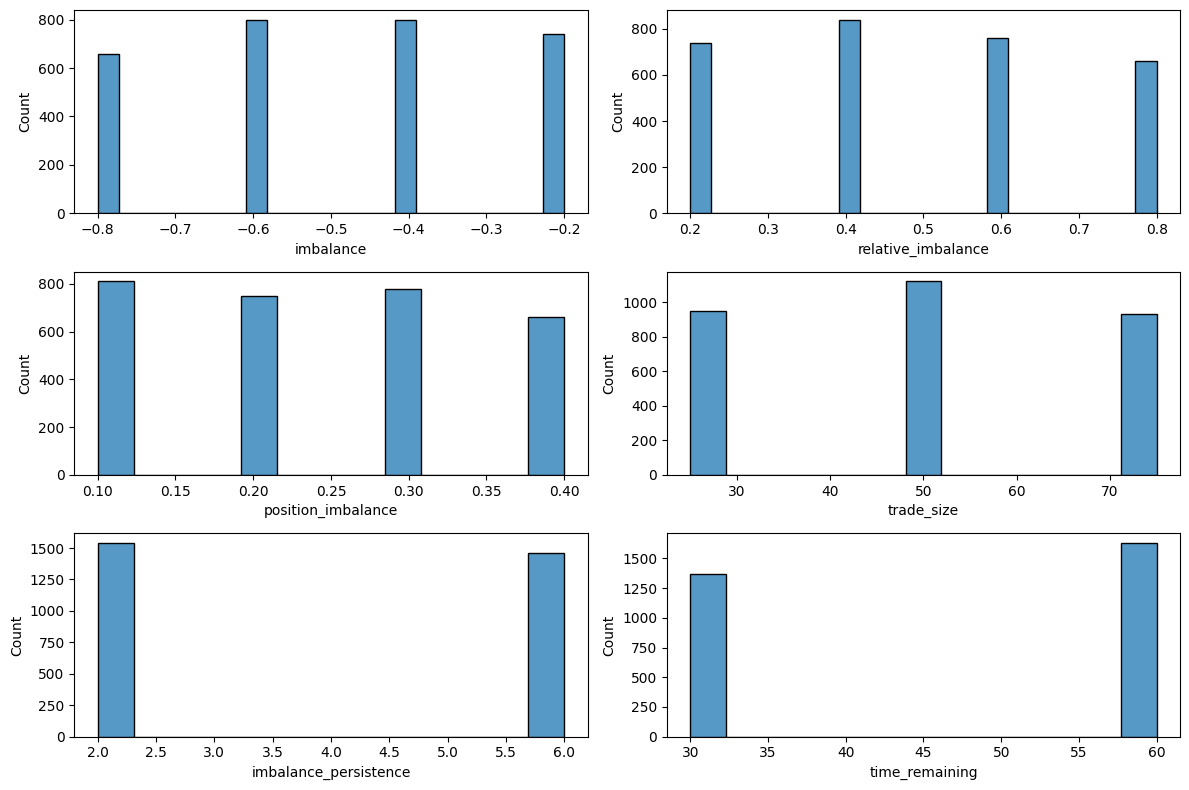

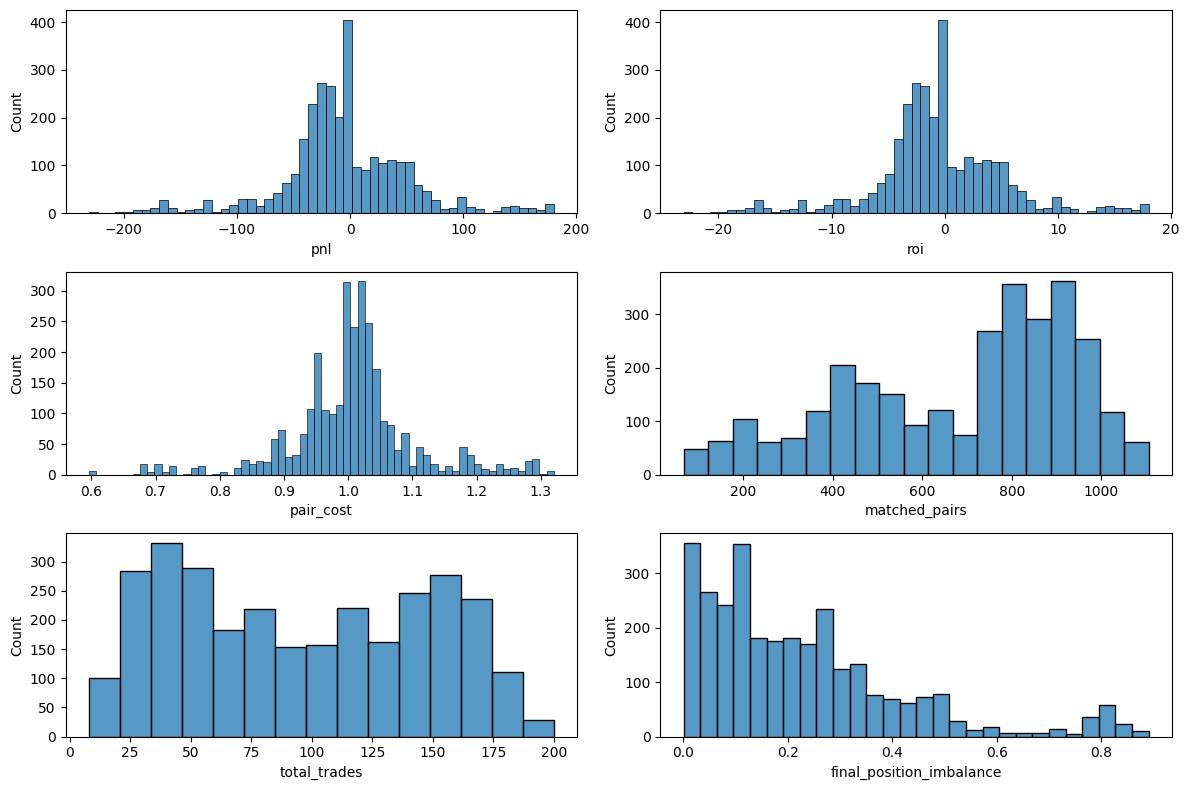

In [965]:
import seaborn as sns

full_results_df = pd.DataFrame(param_results_dict)

grouped_results = full_results_df.groupby(full_results_df.columns[:6].to_list()).agg({
    "pnl": "mean",
    "roi": "mean",
    "pair_cost": "mean",
    "matched_pairs": "mean",
    "total_trades": "mean",
    "final_position_imbalance": "mean",
    "marginal_cost_improvement": "mean"
}).reset_index()

partial_results_df = full_results_df.copy()
# partial_results_df = full_results_df[full_results_df["pair_cost"] < 1]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 8))
param_cols = partial_results_df.columns[:6].to_list()
for ax, col in zip(axes.flatten(), param_cols):
    sns.histplot(partial_results_df, x=col, ax=ax)
fig.tight_layout()
fig.show()


fig2, axes2 = plt.subplots(nrows=3, ncols=2, figsize=(12, 8))
metric_cols = partial_results_df.columns[7:].to_list()
for ax, col in zip(axes2.flatten(), metric_cols):
    sns.histplot(partial_results_df, x=col, ax=ax)
fig2.tight_layout()
fig2.show()

### Improved Strategy and Backing Code

In [ ]:
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple
from itertools import product
from enum import Enum


class MarketState(Enum):
    IDLE = "idle"
    QUOTING = "quoting"
    DEFENSIVE = "defensive"
    PAUSED = "paused"


class MarketRegime(Enum):
    CALM = "calm"
    THIN = "thin"
    TOXIC = "toxic"
    VOLATILE = "volatile"


class PolyMarketBacktester:
    def __init__(self, orderbook: pd.DataFrame, capitol: float = 1_000) -> None:
        self.orderbook = orderbook
        self.initial_capitol = capitol
        self.capitol = capitol

        # Position tracking
        self.avg_up_price = 0
        self.avg_down_price = 0
        self.cum_down_size = 0
        self.cum_up_size = 0
        self.net_position = 0  # cum_up_size - cum_down_size
        self.depth_norm = []  # Typical top-3 size list

        # Trade history
        self.trades = []
        self.pending_orders = []
        self.orderbook_records = orderbook.to_dict("records")

        # State tracking
        self.market_state = MarketState.IDLE
        self.regime_history = []

        # Strategy parameters - Level 1 (hard limits)
        self.pair_cost_max = 1.05  # Max acceptable pair cost
        self.spread_max = 0.10  # Max acceptable relative spread (10%)
        self.depth_min = 10.0  # Min acceptable top3 depth
        self.position_imbalance_limit = 10.0
        self.time_cutoff = 90  # Min seconds remaining
        self.edge_scale = 0.01  # meaningful edge
        self.mp_scale = 1.0  # microprice confidence

        # Level 2 (toxicity)
        self.toxic_thresh = 1.0  # Microprice * depth_imbalance threshold

        # Level 3 (value)
        self.alpha = 1.0  # Weight on imbalance term
        self.trade_threshold = 1.0  # Min value_signal to trade

        # Level 4 (direction)
        self.rel_imb_thresh = 0.001  # Relative imbalance threshold

        # Level 5 (sizing)
        self.base_size = 10.0  # Base trade size in tokens
        self.max_trade_size = 25
        self.liquidity_factor = 0.3  # Take 30% of available depth
        self.inv_scale = 50.0  # Inventory scaling factor

        # State transitions
        self.defensive_spread_thresh = 0.08
        self.defensive_toxic_thresh = 0.25
        self.pause_spread_thresh = 0.12

        # Fee
        self.fee_rate = 0.005  # 0.5% fee per trade

        # Last record in backtest for correct weighting of unmatched inventory
        self.last_record = {}

    @property
    def pair_cost(self):
        """Current average cost of holding one UP and one DOWN"""
        return self.avg_up_price + self.avg_down_price

    @property
    def available_capitol(self):
        """Capitol available for trading"""
        return self.capitol * 0.9  # Keep 10% reserve

    def classify_regime(self, record: Dict) -> MarketRegime:
        """Classify market regime based on current conditions"""
        up_spread = record["up_relative_spread"]
        down_spread = record["down_relative_spread"]
        up_depth = record["up_top3_ask_size"] + record["up_top3_bid_size"]
        down_depth = record["down_top3_ask_size"] + record["down_top3_bid_size"]

        avg_spread = (up_spread + down_spread) / 2
        min_depth = min(up_depth, down_depth)

        # Calculate toxicity
        up_mp = (record["up_microprice"] - record["up_mid"]) / max(
            record["up_spread"], 0.001
        )
        up_toxic = abs(up_mp * record["up_depth_imbalance"])
        down_mp = (record["down_microprice"] - record["down_mid"]) / max(
            record["down_spread"], 0.001
        )
        down_toxic = abs(down_mp * record["down_depth_imbalance"])
        max_toxic = max(up_toxic, down_toxic)

        # Classify
        if max_toxic > self.toxic_thresh:
            return MarketRegime.TOXIC
        elif min_depth < self.depth_min * 1.5:
            return MarketRegime.THIN
        elif avg_spread > self.spread_max * 0.8:
            return MarketRegime.VOLATILE
        else:
            return MarketRegime.CALM

    def update_market_state(self, record: Dict):
        """Update market state based on conditions"""
        up_spread = record["up_relative_spread"]
        down_spread = record["down_relative_spread"]
        max_spread = max(up_spread, down_spread)

        # Calculate toxicity
        up_mp = (record["up_microprice"] - record["up_mid"]) / max(
            record["up_spread"], 0.001
        )
        up_toxic_val = abs(up_mp * record["up_depth_imbalance"])
        down_mp = (record["down_microprice"] - record["down_mid"]) / max(
            record["down_spread"], 0.001
        )
        down_toxic_val = abs(down_mp * record["down_depth_imbalance"])
        max_toxic = max(up_toxic_val, down_toxic_val)

        # Inventory stress
        inv_stress = abs(self.net_position) / self.inv_scale

        # State transitions
        if max_spread > self.pause_spread_thresh or inv_stress > 2.0:
            self.market_state = MarketState.PAUSED
        elif (
            max_spread > self.defensive_spread_thresh
            or max_toxic > self.defensive_toxic_thresh
            or inv_stress > 1.0
        ):
            self.market_state = MarketState.DEFENSIVE
        elif (
            max_spread < self.defensive_spread_thresh * 0.8
            and max_toxic < self.toxic_thresh * 0.8
        ):
            self.market_state = MarketState.QUOTING
        else:
            self.market_state = MarketState.IDLE

    def evaluate_trading_strategy(self, record: Dict) -> Tuple[bool, str, float, str]:
        """
        Combined 5-level trading strategy evaluation
        Returns: (should_trade, direction, size, reason)
        """

        # ========================================================================
        # LEVEL 1: HARD FILTERS - Basic market quality checks
        # ========================================================================

        # Check pair cost
        if record["pair_best_ask"] > self.pair_cost_max:
            return False, None, 0, f"L1: pair_cost too high: {record['pair_best_ask']:.3f}"

        # Check spreads
        max_spread = max(record["up_relative_spread"], record["down_relative_spread"])
        if max_spread > self.spread_max:
            return False, None, 0, f"L1: spread too wide: {max_spread:.3f}"

        # ========================================================================
        # LEVEL 2: TOXICITY CHECK - Assess adverse selection risk
        # ========================================================================

        # Calculate UP toxicity
        up_mp = (record["up_microprice"] - record["up_mid"]) / max(
            record["up_spread"], 0.001
        )
        up_toxic_signal = up_mp * record["up_depth_imbalance"]
        up_toxic = up_toxic_signal > self.toxic_thresh

        # Calculate DOWN toxicity
        down_mp = (record["down_microprice"] - record["down_mid"]) / max(
            record["down_spread"], 0.001
        )
        down_toxic_signal = down_mp * record["down_depth_imbalance"]
        down_toxic = down_toxic_signal > self.toxic_thresh

        # Reject if both sides are toxic
        if up_toxic and down_toxic:
            return False, None, 0, "L2: both sides toxic"

        # ========================================================================
        # LEVEL 3: VALUE SIGNAL - Evaluate trade attractiveness
        # ========================================================================

        # Calculate value signal: lower pair cost + symmetric pressure = better
        pair_best_ask_z = record["pair_best_ask"]
        value_signal = pair_best_ask_z + self.alpha * abs(record["relative_imbalance"])

        # Reject if value signal is too low
        if value_signal < self.trade_threshold:
            return False, None, 0, f"L3: value signal too low: {value_signal:.3f}"

        # ========================================================================
        # LEVEL 4: DIRECTION - Determine which side to trade
        # ========================================================================

        rel_imb = record["relative_imbalance"]

        # Calculate microprice risk for each side
        up_risk = abs(up_mp * record["up_depth_imbalance"])
        down_risk = abs(down_mp * record["down_depth_imbalance"])

        # Evaluate relative imbalance strength
        rel_strength = abs(rel_imb) / self.rel_imb_thresh

        # Determine which sides are safe to trade
        can_trade_up = rel_imb < -self.rel_imb_thresh and not up_toxic
        can_trade_down = rel_imb > self.rel_imb_thresh and not down_toxic

        # Check for weak or ambiguous signal
        if rel_strength < 1.1:
            return False, None, 0, "L4: relative imbalance weak"

        # Determine direction based on imbalance
        direction = None
        if can_trade_up and not can_trade_down:
            direction = "up"
            dir_reason = f"rel_imb {rel_imb:.3f}"
        elif can_trade_down and not can_trade_up:
            direction = "down"
            dir_reason = f"rel_imb {rel_imb:.3f}"
        elif can_trade_up and can_trade_down:
            # Conflict: choose safer side based on microprice risk
            direction = "up" if up_risk < down_risk else "down"
            dir_reason = "chose lower microprice risk"

        # Check inventory constraints
        if direction is None and abs(self.net_position) > self.position_imbalance_limit:
            bias = "up" if self.net_position < 0 else "down"
            return False, None, 0, f"L4: inventory biased toward {bias}"

        if direction is None:
            return False, None, 0, "L4: no valid direction"

        # ========================================================================
        # LEVEL 5: SIZING - Calculate adaptive trade size
        # ========================================================================
        # this needs to be worked on, its stopping a lot of trades in general, should be simpler logic

        # Get side-specific parameters
        if direction == "up":
            available_depth = record["up_top3_ask_size"]
            marginal_pair_cost = (
                record["up_best_ask_price"] + record["down_best_bid_price"]
            )
            inv = self.net_position
            mp_signal = abs(
                (record["up_microprice"] - record["up_mid"])
                / max(record["up_spread"], 0.001)
            )
        else:
            available_depth = record["down_top3_ask_size"]
            marginal_pair_cost = (
                record["down_best_ask_price"] + record["up_best_bid_price"]
            )
            inv = -self.net_position
            mp_signal = abs(
                (record["down_microprice"] - record["down_mid"])
                / max(record["down_spread"], 0.001)
            )

        # Calculate sizing adjustments
        inventory_penalty = np.exp(-max(inv, 0) / self.inv_scale)
        toxicity_penalty = np.exp(-mp_signal / self.mp_scale)
        edge = 1.0 - marginal_pair_cost
        edge_score = np.clip(edge / self.edge_scale, 0, 1)

        # Calculate raw size
        raw_size = (
            self.base_size
            * edge_score
            * inventory_penalty
            * toxicity_penalty
        )

        # Apply hard caps
        size = min(raw_size, available_depth * self.liquidity_factor)
        size = min(size, self.max_trade_size)
        size = max(size, 0)
        size = min(self.base_size, available_depth)

        if size <= 0:
            return False, direction, 0, "L5: size too small"

        # ========================================================================
        # STRATEGY APPROVED
        # ========================================================================

        return True, direction, size, f"APPROVED: {direction} {size:.2f} @ value {value_signal:.3f}"

    def check_pending_orders(self, record: Dict) -> int:
        """
        Check if any pending limit orders should be filled
        Fill if best_ask crosses our bid limit price
        Returns number of filled orders
        """
        filled_orders = []

        for order in self.pending_orders:
            side = order["side"]
            limit_price = order["limit_price"]
            target_size = order["size"]

            # Check if ask price crosses our limit bid price
            if side == "up":
                current_ask = record["up_best_ask_price"]
                available_depth = record["up_top3_ask_size"]

                if current_ask <= limit_price:
                    # Fill at our limit price with fill probability
                    filled = self.execute_limit_fill(
                        order, record, limit_price, available_depth, target_size
                    )
                    if filled:
                        filled_orders.append(order)

            elif side == "down":
                current_ask = record["down_best_ask_price"]
                available_depth = record["down_top3_ask_size"]

                if current_ask <= limit_price:
                    # Fill at our limit price with fill probability
                    filled = self.execute_limit_fill(
                        order, record, limit_price, available_depth, target_size
                    )
                    if filled:
                        filled_orders.append(order)

        # Remove filled orders
        for order in filled_orders:
            self.pending_orders.remove(order)

        return len(filled_orders)

    def simulate_fill_probability(self, size: float, depth: float) -> float:
        """Calculate fill probability based on size vs depth"""
        if size <= depth:
            fill_prob = 0.95
        else:
            fill_prob = depth / size
        return fill_prob

    def execute_limit_fill(
        self, order: Dict, record: Dict, price: float, depth: float, size: float
    ) -> bool:
        """Execute a pending limit order fill"""
        side = order["side"]

        # Simulate fill probability
        fill_prob = self.simulate_fill_probability(size, depth)
        filled_size = size * fill_prob

        if filled_size <= 0:
            return False

        # Calculate cost with fees at our limit price
        cost = filled_size * price * (1 + self.fee_rate)

        # Check if we still have enough capital
        if cost > self.available_capitol:
            return False

        # Execute trade
        self.capitol -= cost
        self.update_avg_price(side, price, filled_size)

        # Record trade
        self.trades.append(
            {
                "timestamp": record["datetime_utc"],
                "side": side,
                "price": price,
                "size": filled_size,
                "fill_prob": fill_prob,
                "cost": cost,
                "fee": filled_size * price * self.fee_rate,
                "capitol_remaining": self.capitol,
                "net_position": self.net_position,
                "pair_cost": self.pair_cost,
                "market_state": self.market_state.value,
                "order_type": "limit_fill",
            }
        )

        return True

    def get_time_remaining(self, record: Dict) -> float:
        """Calculate time remaining in 15-minute window (in seconds)"""
        current_time = record["datetime_utc"]
        next_boundary = current_time.ceil("15min")
        time_remaining = (next_boundary - current_time).total_seconds()
        return time_remaining

    def update_avg_price(self, side: str, price: float, size: float):
        """Update volume-weighted average price for a side"""
        if side == "up":
            total_cost = (self.avg_up_price * self.cum_up_size) + (price * size)
            self.cum_up_size += size
            self.avg_up_price = (
                total_cost / self.cum_up_size if self.cum_up_size > 0 else 0
            )
        elif side == "down":
            total_cost = (self.avg_down_price * self.cum_down_size) + (price * size)
            self.cum_down_size += size
            self.avg_down_price = (
                total_cost / self.cum_down_size if self.cum_down_size > 0 else 0
            )

        # Update net position
        self.net_position = self.cum_up_size - self.cum_down_size

    def execute_trade(self, record: Dict, direction: str, size: float) -> bool:
        """Execute a trade with fill probability"""
        if direction == "up":
            price = record["up_best_ask_price"]
            depth = record["up_top3_ask_size"]
        else:
            price = record["down_best_ask_price"]
            depth = record["down_top3_ask_size"]

        # Simulate fill probability
        fill_prob = self.simulate_fill_probability(size, depth)
        filled_size = size * fill_prob

        if filled_size <= 0:
            return False

        # Calculate cost with fees
        cost = filled_size * price * (1 + self.fee_rate)

        # Check if we have enough capital
        if cost > self.available_capitol:
            return False

        # Execute trade
        self.capitol -= cost
        self.update_avg_price(direction, price, filled_size)

        # Record trade
        self.trades.append(
            {
                "timestamp": record["datetime_utc"],
                "side": direction,
                "price": price,
                "size": filled_size,
                "fill_prob": fill_prob,
                "cost": cost,
                "fee": filled_size * price * self.fee_rate,
                "capitol_remaining": self.capitol,
                "net_position": self.net_position,
                "pair_cost": self.pair_cost,
                "market_state": self.market_state.value,
            }
        )

        return True

    def run_backtest(self, verbose: bool = True, only_results: bool = True):
        """Execute the backtesting strategy"""
        if verbose:
            print(f"Starting backtest with ${self.initial_capitol:.2f}")
            print(f"Total records: {len(self.orderbook_records)}")
            print("=" * 80)

        trade_count = 0
        filter_stats = {
            "level1": 0,
            "level2": 0,
            "level3": 0,
            "level4": 0,
            "level5": 0,
            "success": 0,
        }

        for i, record in enumerate(self.orderbook_records):
            # Store the last record for result calculations
            if i == len(self.orderbook_records) - 1:
                self.last_record = record

            # Check and fill any pending limit orders first
            fills = self.check_pending_orders(record)
            if fills > 0 and verbose and trade_count <= 20:
                print(f"[{i}] 🎯 Filled {fills} limit order(s)")

            # Classify regime
            regime = self.classify_regime(record)
            self.regime_history.append(
                {
                    "timestamp": record["datetime_utc"],
                    "regime": regime.value,
                    "state": self.market_state.value,
                }
            )

            # Update market state
            self.update_market_state(record)

            # Skip if paused
            if self.market_state == MarketState.PAUSED:
                continue

            # Evaluate combined trading strategy
            should_trade, direction, size, reason = self.evaluate_trading_strategy(record)

            # Track which level filtered the trade
            if not should_trade:
                if "L1:" in reason:
                    filter_stats["level1"] += 1
                elif "L2:" in reason:
                    filter_stats["level2"] += 1
                elif "L3:" in reason:
                    filter_stats["level3"] += 1
                elif "L4:" in reason:
                    filter_stats["level4"] += 1
                elif "L5:" in reason:
                    filter_stats["level5"] += 1

                if verbose and not only_results and i % 100 == 0:
                    print(f"[{i}] {reason}")
                continue

            # Execute trade
            traded = self.execute_trade(record, direction, size)

            if traded:
                filter_stats["success"] += 1
                trade_count += 1

                if verbose and not only_results and trade_count <= 20:
                    print(f"\n[{i}] TRADE #{trade_count} @ {record['datetime_utc']}")
                    print(f"  {reason}")
                    print(f"  Direction: {direction.upper()}, Size: {size:.2f}")
                    print(f"  Regime: {regime.value}, State: {self.market_state.value}")
                    print(f"  Net position: {self.net_position:.2f}")
                    print(f"  Capitol: ${self.capitol:.2f}")

        # Print filter statistics
        if verbose:
            print("\n" + "=" * 80)
            print("FILTER STATISTICS")
            print("=" * 80)
            total_records = len(self.orderbook_records)
            print(f"Total records: {total_records}")
            print(
                f"L1 filtered: {filter_stats['level1']} ({100 * filter_stats['level1'] / total_records:.1f}%)"
            )
            print(
                f"L2 filtered: {filter_stats['level2']} ({100 * filter_stats['level2'] / total_records:.1f}%)"
            )
            print(
                f"L3 filtered: {filter_stats['level3']} ({100 * filter_stats['level3'] / total_records:.1f}%)"
            )
            print(
                f"L4 filtered: {filter_stats['level4']} ({100 * filter_stats['level4'] / total_records:.1f}%)"
            )
            print(
                f"L5 filtered: {filter_stats['level5']} ({100 * filter_stats['level5'] / total_records:.1f}%)"
            )
            print(
                f"Trades executed: {filter_stats['success']} ({100 * filter_stats['success'] / total_records:.1f}%)"
            )

        # Calculate final results
        return self.calculate_results(verbose=verbose)

    def calculate_results(self, verbose: bool = True):
        """Calculate and display backtest results"""
        if verbose:
            print("\n" + "=" * 80)
            print("BACKTEST RESULTS")
            print("=" * 80)

        # Position summary
        matched_pairs = min(self.cum_up_size, self.cum_down_size)
        unmatched_up = max(0, self.cum_up_size - self.cum_down_size)
        unmatched_down = max(0, self.cum_down_size - self.cum_up_size)

        if verbose:
            print("\nFinal Position:")
            print(f"  UP tokens: {self.cum_up_size:.2f} @ avg {self.avg_up_price:.3f}")
            print(
                f"  DOWN tokens: {self.cum_down_size:.2f} @ avg {self.avg_down_price:.3f}"
            )
            print(f"  Net position: {self.net_position:.2f}")
            print(f"  Pair cost: {self.pair_cost:.3f}")
            print(f"  Matched pairs: {matched_pairs:.2f}")

        # P&L calculation
        guaranteed_payout = matched_pairs * 1.0
        unmatched_value_up = unmatched_up * np.round(
            self.last_record["up_best_bid_price"], 0
        )
        unmatched_value_down = unmatched_down * np.round(
            self.last_record["down_best_bid_price"], 0
        )

        total_value = (
            self.capitol + guaranteed_payout + unmatched_value_up + unmatched_value_down
        )
        pnl = total_value - self.initial_capitol
        roi = (pnl / self.initial_capitol) * 100

        if verbose:
            print("\nP&L (Conservative):")
            print(f"  Starting capitol: ${self.initial_capitol:.2f}")
            print(f"  Remaining capitol: ${self.capitol:.2f}")
            print(f"  Guaranteed (pairs): ${guaranteed_payout:.2f}")
            print(
                f"  Market Outcome: Up ${np.round(self.last_record['up_best_bid_price'], 0)}, Down ${np.round(self.last_record['down_best_bid_price'], 0)}"
            )
            print(
                f"  Unmatched value: ${unmatched_value_up + unmatched_value_down:.2f}"
            )
            print(f"  Total value: ${total_value:.2f}")
            print(f"  P&L: ${pnl:.2f}")
            print(f"  ROI: {roi:.2f}%")

        # Trade statistics
        trades_df = None
        if self.trades:
            trades_df = pd.DataFrame(self.trades)
            if verbose:
                print("\nTrade Statistics:")
                print(f"  Total trades: {len(trades_df)}")
                print(f"  UP trades: {len(trades_df[trades_df['side'] == 'up'])}")
                print(f"  DOWN trades: {len(trades_df[trades_df['side'] == 'down'])}")
                print(f"  Avg trade size: {trades_df['size'].mean():.2f} tokens")
                print(f"  Avg fill prob: {trades_df['fill_prob'].mean():.2%}")
                print(f"  Total fees: ${trades_df['fee'].sum():.2f}")
                print(f"  Pending (unfilled) orders: {len(self.pending_orders)}")

        # Regime statistics
        if verbose and self.regime_history:
            regime_df = pd.DataFrame(self.regime_history)
            print("\nRegime Distribution:")
            for regime in MarketRegime:
                count = (regime_df["regime"] == regime.value).sum()
                pct = 100 * count / len(regime_df)
                print(f"  {regime.value.upper()}: {count} ({pct:.1f}%)")

        return {
            "trades_df": trades_df,
            "regime_df": pd.DataFrame(self.regime_history)
            if self.regime_history
            else None,
            "pnl": pnl,
            "roi": roi,
            "pair_cost": self.pair_cost,
            "matched_pairs": matched_pairs,
            "total_trades": len(self.trades),
            "net_position": abs(self.net_position),
            "capitol_remaining": self.capitol,
        }


# Example usage
if __name__ == "__main__":
    # Assuming orderbook DataFrame is loaded
    # df_orderbook = pd.read_csv('orderbook_data.csv')

    backtester = PolyMarketBacktester(orderbook=best_prices, capitol=1000)
    results = backtester.run_backtest(verbose=True, only_results=True)

    if results["trades_df"] is not None:
        results["trades_df"].to_csv("trades.csv", index=False)
    if results["regime_df"] is not None:
        results["regime_df"].to_csv("regime_history.csv", index=False)

Starting backtest with $1000.00
Total records: 873

FILTER STATISTICS
Total records: 873
L1 filtered: 0 (0.0%)
L2 filtered: 0 (0.0%)
L3 filtered: 0 (0.0%)
L4 filtered: 0 (0.0%)
L5 filtered: 0 (0.0%)
Trades executed: 55 (6.3%)

BACKTEST RESULTS

Final Position:
  UP tokens: 209.00 @ avg 0.572
  DOWN tokens: 313.50 @ avg 0.430
  Net position: -104.50
  Pair cost: 1.003
  Matched pairs: 209.00

P&L (Conservative):
  Starting capitol: $1000.00
  Remaining capitol: $744.22
  Guaranteed (pairs): $209.00
  Market Outcome: Up $1.0, Down $0.0
  Unmatched value: $0.00
  Total value: $953.22
  P&L: $-46.78
  ROI: -4.68%

Trade Statistics:
  Total trades: 55
  UP trades: 22
  DOWN trades: 33
  Avg trade size: 9.50 tokens
  Avg fill prob: 95.00%
  Total fees: $1.27
  Pending (unfilled) orders: 0

Regime Distribution:
  CALM: 758 (86.8%)
  THIN: 0 (0.0%)
  TOXIC: 3 (0.3%)
  VOLATILE: 112 (12.8%)


In [1211]:
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple


class PolyMarketBacktester:
    def __init__(self, orderbook: pd.DataFrame, capitol: float = 1_000) -> None:
        self.orderbook = orderbook
        self.initial_capitol = capitol
        self.capitol = capitol

        # Position tracking
        self.avg_up_price = 0
        self.avg_down_price = 0
        self.cum_down_size = 0
        self.cum_up_size = 0
        self.net_position = 0  # cum_up_size - cum_down_size

        # Trade history
        self.trades = []
        self.orderbook_records = orderbook.to_dict("records")

        # Strategy parameters
        self.profit_margin = 0.02  # 2% profit target (pair_cost must be < 0.98)
        self.max_position_imbalance = 50.0  # Max delta between up/down positions
        self.base_size = 10.0  # Base trade size
        self.max_trade_size = 100.0  # Max single trade size
        self.liquidity_factor = 0.3  # Use 30% of available depth
        self.rel_imb_thresh = 0.5  # Relative imbalance threshold

        # Fee
        self.fee_rate = 0.005  # 0.5% fee per trade

        # Last record for final valuation
        self.last_record = {}

    @property
    def pair_cost(self):
        """Current average cost of holding one UP and one DOWN"""
        return self.avg_up_price + self.avg_down_price

    @property
    def delta(self):
        """Position imbalance (abs difference between up and down)"""
        return abs(self.cum_up_size - self.cum_down_size)

    @property
    def available_capitol(self):
        """Capitol available for trading"""
        return self.capitol * 0.9  # Keep 10% reserve

    @property
    def target_pair_cost(self):
        """Target pair cost for profitable trades"""
        return 1.0 - self.profit_margin

    def calculate_state(self):
        """Get current position state"""
        return {
            "avg_up": self.avg_up_price,
            "avg_down": self.avg_down_price,
            "pair_cost": self.pair_cost,
            "delta": self.delta,
            "cum_up": self.cum_up_size,
            "cum_down": self.cum_down_size,
        }

    def evaluate_trading_strategy(self, record: Dict) -> Tuple[bool, dict | str | None, float, str]:
        """
        Simplified arbitrage strategy with imbalance filter:
        1. Check relative imbalance signal strength
        2. Check if Ask_UP + avg_DOWN < target_cost OR Ask_DOWN + avg_UP < target_cost
        3. Verify position delta constraint
        4. Calculate safe trade size
        5. Execute best opportunity

        Returns: (should_trade, direction, size, reason)
        """

        # Get best ask prices and available depth
        ask_up = record["up_best_ask_price"]
        ask_down = record["down_best_ask_price"]
        depth_up = record["up_top3_ask_size"]
        depth_down = record["down_top3_ask_size"]

        # Get relative imbalance from record
        rel_imb = record["relative_imbalance"]

        # Calculate current state
        state = self.calculate_state()
        avg_up = state["avg_up"]
        avg_down = state["avg_down"]
        delta = state["delta"]

        # Check if imbalance is strong enough to signal an opportunity
        # imbalance_opp = abs(rel_imb) > self.rel_imb_thresh
        # if not imbalance_opp:
        #     return False, None, 0, f"Imbalance too weak: {rel_imb:.4f}"

        # Find opportunities based on imbalance direction
        opportunity_up = None
        opportunity_down = None

        # Negative relative imbalance suggests buying UP
        # (more pressure/demand on the UP side)
        expected_cost_up = ask_up + avg_down
        if expected_cost_up < self.target_pair_cost:
            opportunity_up = {
                "side": "up",
                "price": ask_up,
                "expected_cost": expected_cost_up,
                "depth": depth_up,
            }

        # Positive relative imbalance suggests buying DOWN
        # (more pressure/demand on the DOWN side)
        expected_cost_down = ask_down + avg_up
        if expected_cost_down < self.target_pair_cost:
            opportunity_down = {
                "side": "down",
                "price": ask_down,
                "expected_cost": expected_cost_down,
                "depth": depth_down,
            }

        # Negative relative imbalance suggests buying UP
        # (more pressure/demand on the UP side)
        if rel_imb < -self.rel_imb_thresh:
            opportunity_up = {
                "side": "up",
                "price": ask_up,
                "expected_cost": expected_cost_up,
                "depth": depth_up,
            }
        # Positive relative imbalance suggests buying DOWN
        # (more pressure/demand on the DOWN side)
        elif rel_imb > self.rel_imb_thresh:
            opportunity_down = {
                "side": "down",
                "price": ask_down,
                "expected_cost": expected_cost_down,
                "depth": depth_down,
            }

        # pair_best_ask_z = record["pair_best_ask"]
        # value_signal = pair_best_ask_z + abs(record["relative_imbalance"])

        # No opportunities found
        if not opportunity_up and not opportunity_down:
            return False, None, 0, f"No profitable opportunities (rel_imb: {rel_imb:.4f})"

        # Choose the opportunity (only one will exist based on imbalance direction)
        chosen = opportunity_up if opportunity_up else opportunity_down

        # Check position delta constraint
        if chosen["side"] == "up":
            new_delta = abs((state["cum_up"] + self.base_size) - state["cum_down"])
        else:
            new_delta = abs(state["cum_up"] - (state["cum_down"] + self.base_size))

        if new_delta > self.max_position_imbalance:
            return False, None, 0, f"Position imbalance too high: {new_delta:.2f}"

        # Calculate trade size
        size = min(
            self.base_size,
            chosen["depth"] * self.liquidity_factor,
            self.max_trade_size
        )

        if size <= 0:
            return False, None, 0, "Trade size too small"

        # Verify we have enough capital
        cost = size * chosen["price"] * (1 + self.fee_rate)
        if cost > self.available_capitol:
            return False, None, 0, f"Insufficient capital: need ${cost:.2f}"

        return True, chosen["side"], size, f"Arbitrage: {chosen['side']} @ {chosen['expected_cost']:.4f} (imb: {rel_imb:.4f})"

    def simulate_fill_probability(self, size: float, depth: float) -> float:
        """Calculate fill probability based on size vs depth"""
        if size <= depth:
            fill_prob = 0.95
        else:
            fill_prob = depth / size
        return fill_prob

    def update_avg_price(self, side: str, price: float, size: float):
        """Update volume-weighted average price for a side"""
        if side == "up":
            total_cost = (self.avg_up_price * self.cum_up_size) + (price * size)
            self.cum_up_size += size
            self.avg_up_price = (
                total_cost / self.cum_up_size if self.cum_up_size > 0 else 0
            )
        elif side == "down":
            total_cost = (self.avg_down_price * self.cum_down_size) + (price * size)
            self.cum_down_size += size
            self.avg_down_price = (
                total_cost / self.cum_down_size if self.cum_down_size > 0 else 0
            )

        # Update net position
        self.net_position = self.cum_up_size - self.cum_down_size

    def execute_trade(self, record: Dict, direction: str, size: float) -> bool:
        """Execute a trade with fill probability"""
        if direction == "up":
            price = record["up_best_ask_price"]
            depth = record["up_top3_ask_size"]
        else:
            price = record["down_best_ask_price"]
            depth = record["down_top3_ask_size"]

        # Simulate fill probability
        fill_prob = self.simulate_fill_probability(size, depth)
        filled_size = size * fill_prob

        if filled_size <= 0:
            return False

        # Calculate cost with fees
        cost = filled_size * price * (1 + self.fee_rate)

        # Check if we have enough capital
        if cost > self.available_capitol:
            return False

        # Execute trade
        self.capitol -= cost
        self.update_avg_price(direction, price, filled_size)

        # Record trade
        self.trades.append(
            {
                "timestamp": record["datetime_utc"],
                "side": direction,
                "price": price,
                "size": filled_size,
                "fill_prob": fill_prob,
                "cost": cost,
                "fee": filled_size * price * self.fee_rate,
                "capitol_remaining": self.capitol,
                "net_position": self.net_position,
                "pair_cost": self.pair_cost,
                "delta": self.delta,
                "rel_imbalance": record["relative_imbalance"],
            }
        )

        return True

    def run_backtest(self, verbose: bool = True, only_results: bool = True):
        """Execute the backtesting strategy"""
        if verbose:
            print(f"Starting backtest with ${self.initial_capitol:.2f}")
            print(f"Total records: {len(self.orderbook_records)}")
            print(f"Profit target: pair_cost < {self.target_pair_cost:.4f}")
            print(f"Relative imbalance threshold: {self.rel_imb_thresh:.4f}")
            print("=" * 80)

        trade_count = 0
        rejected_count = 0

        for i, record in enumerate(self.orderbook_records):
            # Store the last record for result calculations
            if i == len(self.orderbook_records) - 1:
                self.last_record = record

            # Evaluate trading strategy
            should_trade, direction, size, reason = self.evaluate_trading_strategy(record)

            if not should_trade:
                rejected_count += 1
                if verbose and not only_results and i % 500 == 0:
                    print(f"[{i}] Rejected: {reason}")
                continue

            # Execute trade
            traded = self.execute_trade(record, direction, size)

            if traded:
                trade_count += 1

                if verbose and not only_results and trade_count <= 20:
                    print(f"\n[{i}] TRADE #{trade_count} @ {record['datetime_utc']}")
                    print(f"  {reason}")
                    print(f"  Direction: {direction.upper()}, Size: {size:.2f}")
                    print(f"  Pair cost: {self.pair_cost:.4f}")
                    print(f"  Delta: {self.delta:.2f}")
                    print(f"  Capitol: ${self.capitol:.2f}")

        # Print summary statistics
        if verbose:
            print("\n" + "=" * 80)
            print("TRADING STATISTICS")
            print("=" * 80)
            total_records = len(self.orderbook_records)
            print(f"Total records scanned: {total_records}")
            print(f"Trades executed: {trade_count} ({100 * trade_count / total_records:.2f}%)")
            print(f"Opportunities rejected: {rejected_count} ({100 * rejected_count / total_records:.2f}%)")

        # Calculate final results
        return self.calculate_results(verbose=verbose)

    def calculate_results(self, verbose: bool = True):
        """Calculate and display backtest results"""
        if verbose:
            print("\n" + "=" * 80)
            print("BACKTEST RESULTS")
            print("=" * 80)

        # Position summary
        matched_pairs = min(self.cum_up_size, self.cum_down_size)
        unmatched_up = max(0, self.cum_up_size - self.cum_down_size)
        unmatched_down = max(0, self.cum_down_size - self.cum_up_size)

        if verbose:
            print("\nFinal Position:")
            print(f"  UP tokens: {self.cum_up_size:.2f} @ avg {self.avg_up_price:.4f}")
            print(f"  DOWN tokens: {self.cum_down_size:.2f} @ avg {self.avg_down_price:.4f}")
            print(f"  Delta (imbalance): {self.delta:.2f}")
            print(f"  Pair cost: {self.pair_cost:.4f}")
            print(f"  Matched pairs: {matched_pairs:.2f}")

        # P&L calculation
        guaranteed_payout = matched_pairs * 1.0
        unmatched_value_up = unmatched_up * np.round(
            self.last_record["up_best_bid_price"], 0
        )
        unmatched_value_down = unmatched_down * np.round(
            self.last_record["down_best_bid_price"], 0
        )

        total_value = (
            self.capitol + guaranteed_payout + unmatched_value_up + unmatched_value_down
        )
        pnl = total_value - self.initial_capitol
        roi = (pnl / self.initial_capitol) * 100

        if verbose:
            print("\nP&L:")
            print(f"  Starting capitol: ${self.initial_capitol:.2f}")
            print(f"  Remaining capitol: ${self.capitol:.2f}")
            print(f"  Guaranteed (pairs): ${guaranteed_payout:.2f}")
            print(
                f"  Market Outcome: Up ${np.round(self.last_record['up_best_bid_price'], 0)}, "
                f"Down ${np.round(self.last_record['down_best_bid_price'], 0)}"
            )
            print(f"  Unmatched value: ${unmatched_value_up + unmatched_value_down:.2f}")
            print(f"  Total value: ${total_value:.2f}")
            print(f"  P&L: ${pnl:.2f}")
            print(f"  ROI: {roi:.2f}%")

        # Trade statistics
        trades_df = None
        if self.trades:
            trades_df = pd.DataFrame(self.trades)
            if verbose:
                print("\nTrade Statistics:")
                print(f"  Total trades: {len(trades_df)}")
                print(f"  UP trades: {len(trades_df[trades_df['side'] == 'up'])}")
                print(f"  DOWN trades: {len(trades_df[trades_df['side'] == 'down'])}")
                print(f"  Avg trade size: {trades_df['size'].mean():.2f} tokens")
                print(f"  Avg fill probability: {trades_df['fill_prob'].mean():.2%}")
                print(f"  Total fees paid: ${trades_df['fee'].sum():.2f}")
                print(f"  Avg rel_imbalance: {trades_df['rel_imbalance'].mean():.4f}")

        return {
            "trades_df": trades_df,
            "pnl": pnl,
            "roi": roi,
            "pair_cost": self.pair_cost,
            "matched_pairs": matched_pairs,
            "total_trades": len(self.trades),
            "delta": self.delta,
            "capitol_remaining": self.capitol,
        }


# Example usage
if __name__ == "__main__":
    # Assuming orderbook DataFrame is loaded
    # df_orderbook = pd.read_csv('orderbook_data.csv')

    backtester = PolyMarketBacktester(orderbook=best_prices, capitol=100)
    results = backtester.run_backtest(verbose=True, only_results=True)

    if results["trades_df"] is not None:
        results["trades_df"].to_csv("trades.csv", index=False)

Starting backtest with $100.00
Total records: 873
Profit target: pair_cost < 0.9800
Relative imbalance threshold: 0.5000

TRADING STATISTICS
Total records scanned: 873
Trades executed: 25 (2.86%)
Opportunities rejected: 848 (97.14%)

BACKTEST RESULTS

Final Position:
  UP tokens: 114.00 @ avg 0.7742
  DOWN tokens: 123.50 @ avg 0.0508
  Delta (imbalance): 9.50
  Pair cost: 0.8249
  Matched pairs: 114.00

P&L:
  Starting capitol: $100.00
  Remaining capitol: $5.00
  Guaranteed (pairs): $114.00
  Market Outcome: Up $1.0, Down $0.0
  Unmatched value: $0.00
  Total value: $119.00
  P&L: $19.00
  ROI: 19.00%

Trade Statistics:
  Total trades: 25
  UP trades: 12
  DOWN trades: 13
  Avg trade size: 9.50 tokens
  Avg fill probability: 95.00%
  Total fees paid: $0.47
  Avg rel_imbalance: 0.2674


In [1230]:
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple


class PolyMarketBacktester:
    def __init__(self, orderbook: pd.DataFrame, capitol: float = 1_000) -> None:
        self.orderbook = orderbook
        self.initial_capitol = capitol
        self.capitol = capitol

        # Position tracking
        self.avg_up_price = 0
        self.avg_down_price = 0
        self.cum_down_size = 0
        self.cum_up_size = 0
        self.net_position = 0  # cum_up_size - cum_down_size

        # Trade history
        self.trades = []
        self.orderbook_records = orderbook.to_dict("records")

        # Strategy parameters
        self.profit_margin = 0.02  # 2% profit target (pair_cost must be < 0.98)
        self.max_position_imbalance = 50.0  # Max delta between up/down positions (will decay)
        self.base_size = 10.0  # Base trade size
        self.max_trade_size = 100.0  # Max single trade size
        self.liquidity_factor = 0.6  # Use 60% of available depth
        self.rel_imb_thresh = 0.5  # Relative imbalance threshold
        self.imbalance_target_buffer = 0.9  # When to start targeting imbalance (90% of threshold)

        # Imbalance decay parameters
        self.imbalance_decay_enabled = True
        self.initial_max_imbalance = 50.0  # Starting max imbalance (high early on)
        self.final_max_imbalance = 5.0  # Ending max imbalance (low at end)
        self.decay_start_pct = 0.3  # Start decaying after 30% of data
        self.decay_type = "exponential"  # Options: "linear", "exponential", "sigmoid"

        # Endgame parameters
        self.endgame_enabled = True
        self.endgame_lookback = 50  # Look at last N records to determine if in endgame
        self.endgame_threshold = 0.75  # Start endgame when avg price > 0.75 or < 0.25
        self.endgame_max_pair_cost = 0.98  # Maximum pair cost allowed in endgame
        self.endgame_ideal_pair_cost = 0.98  # Ideal target for endgame pair cost

        # Fee
        self.fee_rate = 0.005  # 0.5% fee per trade

        # Last record for final valuation
        self.last_record = {}

    def get_current_max_imbalance(self, current_index: int) -> float:
        """
        Calculate current max position imbalance based on progress through data.
        Decays from initial_max_imbalance to final_max_imbalance.

        Args:
            current_index: Current position in orderbook_records

        Returns:
            Current maximum allowed position imbalance
        """
        if not self.imbalance_decay_enabled:
            return self.max_position_imbalance

        total_records = len(self.orderbook_records)
        progress = current_index / total_records  # 0.0 to 1.0

        # Don't start decaying until decay_start_pct
        if progress < self.decay_start_pct:
            return self.initial_max_imbalance

        # Normalize progress for decay period
        decay_progress = (progress - self.decay_start_pct) / (1.0 - self.decay_start_pct)

        if self.decay_type == "linear":
            # Linear decay from initial to final
            current_max = self.initial_max_imbalance - (
                (self.initial_max_imbalance - self.final_max_imbalance) * decay_progress
            )

        elif self.decay_type == "exponential":
            # Exponential decay (faster at start, slower at end)
            decay_rate = 3.0  # Higher = faster decay
            decay_factor = np.exp(-decay_rate * decay_progress)
            current_max = self.final_max_imbalance + (
                (self.initial_max_imbalance - self.final_max_imbalance) * decay_factor
            )

        elif self.decay_type == "sigmoid":
            # Sigmoid decay (slow-fast-slow)
            midpoint = 0.5
            steepness = 10.0
            sigmoid = 1 / (1 + np.exp(-steepness * (decay_progress - midpoint)))
            current_max = self.initial_max_imbalance - (
                (self.initial_max_imbalance - self.final_max_imbalance) * sigmoid
            )

        else:
            # Default to linear
            current_max = self.initial_max_imbalance - (
                (self.initial_max_imbalance - self.final_max_imbalance) * decay_progress
            )

        return current_max

    @property
    def pair_cost(self):
        """Current average cost of holding one UP and one DOWN"""
        return self.avg_up_price + self.avg_down_price

    @property
    def delta(self):
        """Position imbalance (abs difference between up and down)"""
        return abs(self.cum_up_size - self.cum_down_size)

    @property
    def available_capitol(self):
        """Capitol available for trading"""
        return self.capitol * 0.9  # Keep 10% reserve

    @property
    def target_pair_cost(self):
        """Target pair cost for profitable trades"""
        return 1.0 - self.profit_margin

    def calculate_state(self):
        """Get current position state"""
        return {
            "avg_up": self.avg_up_price,
            "avg_down": self.avg_down_price,
            "pair_cost": self.pair_cost,
            "delta": self.delta,
            "cum_up": self.cum_up_size,
            "cum_down": self.cum_down_size,
        }

    def is_endgame(self, record: Dict, current_index: int) -> Tuple[bool, str, float]:
        """
        Determine if we're in endgame and which direction is favored.

        Returns: (is_endgame, favored_direction, confidence)
        """
        if not self.endgame_enabled:
            return False, None, 0.0

        # Check if we're near the end of the data
        total_records = len(self.orderbook_records)
        records_remaining = total_records - current_index

        # Get current market prices
        up_price = record["up_best_ask_price"]
        down_price = record["down_best_ask_price"]

        # Determine if market is showing clear direction
        # If UP price is very high (>0.75), UP outcome is likely
        # If DOWN price is very high (>0.75), DOWN outcome is likely

        if up_price > self.endgame_threshold:
            return True, "up", up_price
        elif down_price > self.endgame_threshold:
            return True, "down", down_price

        return False, None, 0.0

    def calculate_endgame_target_imbalance(self, favored_direction: str, confidence: float) -> float:
        """
        Calculate how much imbalance we want in the favored direction.
        Higher confidence = more aggressive imbalance.
        """
        # Base imbalance scales with confidence
        # At 0.75 confidence: target ~10 imbalance
        # At 0.90 confidence: target ~30 imbalance
        base_imbalance = (confidence - 0.5) * 60  # Scale from 0.5-1.0 to 0-30

        return min(base_imbalance, self.max_position_imbalance * 2)  # Allow 2x normal imbalance in endgame

    def evaluate_endgame_strategy(self, record: Dict, favored_direction: str, confidence: float, current_index: int) -> Tuple[bool, str, float, str]:
        """
        Endgame strategy: Tilt position toward the likely winner while maintaining pair_cost <= 0.98

        Strategy:
        1. If we have imbalance in the WRONG direction, hedge it first
        2. If balanced or imbalanced in RIGHT direction, increase imbalance toward favored side
        3. Always ensure new avg prices maintain pair_cost <= 0.98
        """
        state = self.calculate_state()

        # Get current prices
        ask_up = record["up_best_ask_price"]
        ask_down = record["down_best_ask_price"]
        depth_up = record["up_top3_ask_size"]
        depth_down = record["down_top3_ask_size"]

        avg_up = state["avg_up"]
        avg_down = state["avg_down"]

        # Calculate target imbalance based on confidence
        target_imbalance = self.calculate_endgame_target_imbalance(favored_direction, confidence)

        # Get current dynamic max imbalance (for safety checks)
        current_max_imbalance = self.get_current_max_imbalance(current_index)

        # Determine current imbalance direction
        if self.cum_up_size > self.cum_down_size:
            current_imbalance_direction = "up"
            current_imbalance = self.cum_up_size - self.cum_down_size
        elif self.cum_down_size > self.cum_up_size:
            current_imbalance_direction = "down"
            current_imbalance = self.cum_down_size - self.cum_up_size
        else:
            current_imbalance_direction = None
            current_imbalance = 0

        # CASE 1: We're imbalanced in the WRONG direction - hedge first
        if current_imbalance_direction and current_imbalance_direction != favored_direction:
            if favored_direction == "up":
                # Need to buy UP to reduce DOWN excess
                new_avg_up = (avg_up * self.cum_up_size + ask_up * self.base_size) / (self.cum_up_size + self.base_size)
                new_pair_cost = new_avg_up + avg_down

                if new_pair_cost <= self.endgame_max_pair_cost:
                    size = min(self.base_size, depth_up * self.liquidity_factor, self.max_trade_size, current_imbalance)
                    if size > 0:
                        cost = size * ask_up * (1 + self.fee_rate)
                        if cost <= self.available_capitol:
                            return True, "up", size, f"ENDGAME_HEDGE: Correct to UP @ {new_pair_cost:.4f} (conf: {confidence:.2f})"
            else:  # favored_direction == "down"
                # Need to buy DOWN to reduce UP excess
                new_avg_down = (avg_down * self.cum_down_size + ask_down * self.base_size) / (self.cum_down_size + self.base_size)
                new_pair_cost = avg_up + new_avg_down

                if new_pair_cost <= self.endgame_max_pair_cost:
                    size = min(self.base_size, depth_down * self.liquidity_factor, self.max_trade_size, current_imbalance)
                    if size > 0:
                        cost = size * ask_down * (1 + self.fee_rate)
                        if cost <= self.available_capitol:
                            return True, "down", size, f"ENDGAME_HEDGE: Correct to DOWN @ {new_pair_cost:.4f} (conf: {confidence:.2f})"

        # CASE 2: We're balanced or imbalanced in RIGHT direction - increase imbalance
        if current_imbalance < target_imbalance:
            if favored_direction == "up":
                # Buy more UP to increase UP imbalance
                new_avg_up = (avg_up * self.cum_up_size + ask_up * self.base_size) / (self.cum_up_size + self.base_size)
                new_pair_cost = new_avg_up + avg_down

                if new_pair_cost <= self.endgame_max_pair_cost:
                    needed = target_imbalance - current_imbalance
                    size = min(self.base_size, depth_up * self.liquidity_factor, self.max_trade_size, needed)
                    if size > 0:
                        cost = size * ask_up * (1 + self.fee_rate)
                        if cost <= self.available_capitol:
                            return True, "up", size, f"ENDGAME_TILT: Build UP position @ {new_pair_cost:.4f} (target imb: {target_imbalance:.1f})"
            else:  # favored_direction == "down"
                # Buy more DOWN to increase DOWN imbalance
                new_avg_down = (avg_down * self.cum_down_size + ask_down * self.base_size) / (self.cum_down_size + self.base_size)
                new_pair_cost = avg_up + new_avg_down

                if new_pair_cost <= self.endgame_max_pair_cost:
                    needed = target_imbalance - current_imbalance
                    size = min(self.base_size, depth_down * self.liquidity_factor, self.max_trade_size, needed)
                    if size > 0:
                        cost = size * ask_down * (1 + self.fee_rate)
                        if cost <= self.available_capitol:
                            return True, "down", size, f"ENDGAME_TILT: Build DOWN position @ {new_pair_cost:.4f} (target imb: {target_imbalance:.1f})"

        # CASE 3: We've achieved target imbalance with good pair cost - stop trading
        if current_imbalance >= target_imbalance and self.pair_cost <= self.endgame_ideal_pair_cost:
            return False, None, 0, f"ENDGAME_COMPLETE: Target reached (imb: {current_imbalance:.1f}, pair_cost: {self.pair_cost:.4f})"

        return False, None, 0, f"ENDGAME_WAIT: No valid endgame opportunity (pair_cost would exceed {self.endgame_max_pair_cost:.4f})"

    def evaluate_trading_strategy(self, record: Dict, current_index: int = 0) -> Tuple[bool, str, float, str]:
        """
        Multi-phase trading strategy with endgame logic:

        ENDGAME: If market shows clear direction, tilt position toward winner
        PHASE 1 (Bootstrap): If either position is 0, build initial balanced position
        PHASE 2 (Hedge): If imbalanced, prioritize hedging to lock in profit
        PHASE 3 (Atomic Open): If balanced, look for profitable atomic pair entries
        PHASE 4 (Imbalance Signal): Use market imbalance as directional signal

        Returns: (should_trade, direction, size, reason)
        """

        # Check if we're in endgame
        is_endgame, favored_direction, confidence = self.is_endgame(record, current_index)

        if is_endgame:
            # Use endgame strategy
            return self.evaluate_endgame_strategy(record, favored_direction, confidence, current_index)

        # Get best ask prices and available depth
        ask_up = record["up_best_ask_price"]
        ask_down = record["down_best_ask_price"]
        depth_up = record["up_top3_ask_size"]
        depth_down = record["down_top3_ask_size"]

        # Get relative imbalance from record
        rel_imb = record["relative_imbalance"]

        # Calculate current state
        state = self.calculate_state()
        avg_up = state["avg_up"]
        avg_down = state["avg_down"]
        delta = state["delta"]

        # Get current dynamic max imbalance
        current_max_imbalance = self.get_current_max_imbalance(current_index)

        # ========================================================================
        # PHASE 1: BOOTSTRAP - Build initial positions
        # ========================================================================

        # If we have no UP position, buy UP first to avoid directional exposure
        if self.cum_up_size == 0:
            size = min(self.base_size, depth_up * self.liquidity_factor, self.max_trade_size)
            if size > 0:
                cost = size * ask_up * (1 + self.fee_rate)
                if cost <= self.available_capitol:
                    return True, "up", size, f"BOOTSTRAP: Initial UP position @ {ask_up:.4f}"

        # If we have no DOWN position, buy DOWN to avoid directional exposure
        if self.cum_down_size == 0:
            size = min(self.base_size, depth_down * self.liquidity_factor, self.max_trade_size)
            if size > 0:
                cost = size * ask_down * (1 + self.fee_rate)
                if cost <= self.available_capitol:
                    return True, "down", size, f"BOOTSTRAP: Initial DOWN position @ {ask_down:.4f}"

        # ========================================================================
        # PHASE 2: HEDGE - Prioritize locking in profit when imbalanced
        # ========================================================================

        # If we have more UP than DOWN, look to buy DOWN to hedge
        if self.cum_up_size > self.cum_down_size:
            potential_pair_cost = ask_down + avg_up
            if potential_pair_cost < self.target_pair_cost:
                # Calculate size needed to neutralize delta
                needed = self.cum_up_size - self.cum_down_size
                size = min(needed, depth_down * self.liquidity_factor, self.base_size, self.max_trade_size)
                if size > 0:
                    cost = size * ask_down * (1 + self.fee_rate)
                    if cost <= self.available_capitol:
                        return True, "down", size, f"HEDGE: Lock profit DOWN @ {potential_pair_cost:.4f}"

        # If we have more DOWN than UP, look to buy UP to hedge
        elif self.cum_down_size > self.cum_up_size:
            potential_pair_cost = ask_up + avg_down
            if potential_pair_cost < self.target_pair_cost:
                # Calculate size needed to neutralize delta
                needed = self.cum_down_size - self.cum_up_size
                size = min(needed, depth_up * self.liquidity_factor, self.base_size, self.max_trade_size)
                if size > 0:
                    cost = size * ask_up * (1 + self.fee_rate)
                    if cost <= self.available_capitol:
                        return True, "up", size, f"HEDGE: Lock profit UP @ {potential_pair_cost:.4f}"

        # ========================================================================
        # PHASE 3: ATOMIC OPEN - Buy both sides simultaneously if cheap
        # ========================================================================

        combined_market_cost = ask_up + ask_down

        # Only enter new positions atomically if we can buy BOTH sides profitably
        if combined_market_cost < self.target_pair_cost:
            size = min(self.base_size, depth_up * self.liquidity_factor, depth_down * self.liquidity_factor, self.max_trade_size)
            if size > 0:
                # Check if we can afford both sides
                total_cost = size * combined_market_cost * (1 + self.fee_rate)
                if total_cost <= self.available_capitol:
                    # For atomic open, we'll execute both in sequence
                    # Return the first trade (UP), and the second will be caught on next iteration
                    return True, "up", size, f"ATOMIC_OPEN: Both sides @ {combined_market_cost:.4f}"

        # ========================================================================
        # PHASE 4: IMBALANCE TARGETING - Target side close to threshold
        # ========================================================================

        # Check if we're approaching the imbalance threshold (within 90% of limit)
        approaching_limit = delta > (current_max_imbalance * self.imbalance_target_buffer)

        if approaching_limit:
            # Determine which side to target to reduce imbalance
            if self.cum_up_size > self.cum_down_size:
                # We have excess UP, target DOWN
                target_side = "down"
                target_price = ask_down
                target_depth = depth_down
                expected_cost = ask_down + avg_up
            else:
                # We have excess DOWN, target UP
                target_side = "up"
                target_price = ask_up
                target_depth = depth_up
                expected_cost = ask_up + avg_down

            # More aggressive sizing when approaching limit
            size = min(
                self.base_size * 1.5,  # 50% larger trades when targeting
                target_depth * self.liquidity_factor,
                self.max_trade_size
            )

            if size > 0:
                cost = size * target_price * (1 + self.fee_rate)
                if cost <= self.available_capitol:
                    return True, target_side, size, f"IMBALANCE_TARGET: {target_side} @ {expected_cost:.4f} (delta: {delta:.2f}, max: {current_max_imbalance:.2f})"

        # ========================================================================
        # PHASE 5: STANDARD ARBITRAGE - Look for profitable opportunities
        # ========================================================================

        opportunity_up = None
        opportunity_down = None

        # Check UP opportunity
        expected_cost_up = ask_up + avg_down
        if expected_cost_up < self.target_pair_cost:
            opportunity_up = {
                "side": "up",
                "price": ask_up,
                "expected_cost": expected_cost_up,
                "depth": depth_up,
            }

        # Check DOWN opportunity
        expected_cost_down = ask_down + avg_up
        if expected_cost_down < self.target_pair_cost:
            opportunity_down = {
                "side": "down",
                "price": ask_down,
                "expected_cost": expected_cost_down,
                "depth": depth_down,
            }

        # Use imbalance signal to choose direction
        if rel_imb < -self.rel_imb_thresh and opportunity_up:
            chosen = opportunity_up
        elif rel_imb > self.rel_imb_thresh and opportunity_down:
            chosen = opportunity_down
        elif opportunity_up and opportunity_down:
            # Choose better opportunity
            chosen = opportunity_up if expected_cost_up < expected_cost_down else opportunity_down
        elif opportunity_up:
            chosen = opportunity_up
        elif opportunity_down:
            chosen = opportunity_down
        else:
            return False, None, 0, f"No opportunities (pair_cost UP: {expected_cost_up:.4f}, DOWN: {expected_cost_down:.4f}, imb: {rel_imb:.4f})"

        # ========================================================================
        # POSITION DELTA CONSTRAINT
        # ========================================================================

        # Check position delta constraint using dynamic max imbalance
        if chosen["side"] == "up":
            new_delta = abs((state["cum_up"] + self.base_size) - state["cum_down"])
        else:
            new_delta = abs(state["cum_up"] - (state["cum_down"] + self.base_size))

        if new_delta > current_max_imbalance:
            return False, None, 0, f"Position imbalance too high: {new_delta:.2f} (max: {current_max_imbalance:.2f})"

        # ========================================================================
        # CALCULATE TRADE SIZE
        # ========================================================================

        size = min(
            self.base_size,
            chosen["depth"] * self.liquidity_factor,
            self.max_trade_size
        )

        if size <= 0:
            return False, None, 0, "Trade size too small"

        # ========================================================================
        # CAPITAL CHECK
        # ========================================================================

        cost = size * chosen["price"] * (1 + self.fee_rate)
        if cost > self.available_capitol:
            return False, None, 0, f"Insufficient capital: need ${cost:.2f}"

        return True, chosen["side"], size, f"ARBITRAGE: {chosen['side']} @ {chosen['expected_cost']:.4f} (imb: {rel_imb:.4f})"

    def simulate_fill_probability(self, size: float, depth: float) -> float:
        """Calculate fill probability based on size vs depth"""
        if size <= depth:
            fill_prob = 0.95
        else:
            fill_prob = depth / size
        return fill_prob

    def update_avg_price(self, side: str, price: float, size: float):
        """Update volume-weighted average price for a side"""
        if side == "up":
            total_cost = (self.avg_up_price * self.cum_up_size) + (price * size)
            self.cum_up_size += size
            self.avg_up_price = (
                total_cost / self.cum_up_size if self.cum_up_size > 0 else 0
            )
        elif side == "down":
            total_cost = (self.avg_down_price * self.cum_down_size) + (price * size)
            self.cum_down_size += size
            self.avg_down_price = (
                total_cost / self.cum_down_size if self.cum_down_size > 0 else 0
            )

        # Update net position
        self.net_position = self.cum_up_size - self.cum_down_size

    def execute_trade(self, record: Dict, direction: str, size: float, reason: str = "") -> bool:
        """Execute a trade with fill probability"""
        if direction == "up":
            price = record["up_best_ask_price"]
            depth = record["up_top3_ask_size"]
        else:
            price = record["down_best_ask_price"]
            depth = record["down_top3_ask_size"]

        # Simulate fill probability
        fill_prob = self.simulate_fill_probability(size, depth)
        filled_size = size * fill_prob

        if filled_size <= 0:
            return False

        # Calculate cost with fees
        cost = filled_size * price * (1 + self.fee_rate)

        # Check if we have enough capital
        if cost > self.available_capitol:
            return False

        # Execute trade
        self.capitol -= cost
        self.update_avg_price(direction, price, filled_size)

        # Extract signal type from reason
        signal_type = reason.split(":")[0] if ":" in reason else "UNKNOWN"

        # Record trade
        self.trades.append(
            {
                "timestamp": record["datetime_utc"],
                "side": direction,
                "price": price,
                "size": filled_size,
                "fill_prob": fill_prob,
                "cost": cost,
                "fee": filled_size * price * self.fee_rate,
                "capitol_remaining": self.capitol,
                "net_position": self.net_position,
                "pair_cost": self.pair_cost,
                "delta": self.delta,
                "rel_imbalance": record["relative_imbalance"],
                "signal_type": signal_type,
            }
        )

        return True

    def run_backtest(self, verbose: bool = True, only_results: bool = True):
        """Execute the backtesting strategy"""
        if verbose:
            print(f"Starting backtest with ${self.initial_capitol:.2f}")
            print(f"Total records: {len(self.orderbook_records)}")
            print(f"Profit target: pair_cost < {self.target_pair_cost:.4f}")
            print(f"Relative imbalance threshold: {self.rel_imb_thresh:.4f}")
            if self.imbalance_decay_enabled:
                print(f"Dynamic max imbalance: {self.initial_max_imbalance:.2f} → {self.final_max_imbalance:.2f}")
                print(f"Decay starts at: {self.decay_start_pct * 100:.0f}% of data")
                print(f"Decay type: {self.decay_type}")
            else:
                print(f"Max position imbalance: {self.max_position_imbalance:.2f}")
            print(f"Imbalance target buffer: {self.imbalance_target_buffer * 100:.0f}%")
            print(f"Endgame enabled: {self.endgame_enabled}")
            print(f"Endgame threshold: {self.endgame_threshold:.2f}")
            print(f"Endgame max pair cost: {self.endgame_max_pair_cost:.4f}")
            print("=" * 80)

        trade_count = 0
        rejected_count = 0
        signal_counts = {}

        for i, record in enumerate(self.orderbook_records):
            # Store the last record for result calculations
            if i == len(self.orderbook_records) - 1:
                self.last_record = record

            # Evaluate trading strategy (pass index for endgame detection)
            should_trade, direction, size, reason = self.evaluate_trading_strategy(record, i)

            if not should_trade:
                rejected_count += 1
                if verbose and not only_results and i % 500 == 0:
                    current_max_imb = self.get_current_max_imbalance(i)
                    print(f"[{i}] Rejected: {reason} [max_imb: {current_max_imb:.2f}]")
                continue

            # Execute trade
            traded = self.execute_trade(record, direction, size, reason)

            if traded:
                trade_count += 1

                # Track signal types
                signal_type = reason.split(":")[0]
                signal_counts[signal_type] = signal_counts.get(signal_type, 0) + 1

                if verbose and not only_results and trade_count <= 30:
                    current_max_imb = self.get_current_max_imbalance(i)
                    print(f"\n[{i}] TRADE #{trade_count} @ {record['datetime_utc']}")
                    print(f"  {reason}")
                    print(f"  Direction: {direction.upper()}, Size: {size:.2f}")
                    print(f"  Pair cost: {self.pair_cost:.4f}")
                    print(f"  Delta: {self.delta:.2f} (max: {current_max_imb:.2f})")
                    print(f"  Capitol: ${self.capitol:.2f}")

        # Print summary statistics
        if verbose:
            print("\n" + "=" * 80)
            print("TRADING STATISTICS")
            print("=" * 80)
            total_records = len(self.orderbook_records)
            print(f"Total records scanned: {total_records}")
            print(f"Trades executed: {trade_count} ({100 * trade_count / total_records:.2f}%)")

            # Print signal breakdown
            if signal_counts:
                print("\nSignal Type Breakdown:")
                for signal_type, count in sorted(signal_counts.items(), key=lambda x: x[1], reverse=True):
                    pct = 100 * count / trade_count
                    print(f"  {signal_type}: {count} ({pct:.1f}%)")

            print(f"\nOpportunities rejected: {rejected_count} ({100 * rejected_count / total_records:.2f}%)")

        # Calculate final results
        return self.calculate_results(verbose=verbose)

    def calculate_results(self, verbose: bool = True):
        """Calculate and display backtest results"""
        if verbose:
            print("\n" + "=" * 80)
            print("BACKTEST RESULTS")
            print("=" * 80)

        # Position summary
        matched_pairs = min(self.cum_up_size, self.cum_down_size)
        unmatched_up = max(0, self.cum_up_size - self.cum_down_size)
        unmatched_down = max(0, self.cum_down_size - self.cum_up_size)

        if verbose:
            print("\nFinal Position:")
            print(f"  UP tokens: {self.cum_up_size:.2f} @ avg {self.avg_up_price:.4f}")
            print(f"  DOWN tokens: {self.cum_down_size:.2f} @ avg {self.avg_down_price:.4f}")
            print(f"  Delta (imbalance): {self.delta:.2f}")
            print(f"  Pair cost: {self.pair_cost:.4f}")
            print(f"  Matched pairs: {matched_pairs:.2f}")

        # P&L calculation
        guaranteed_payout = matched_pairs * 1.0
        unmatched_value_up = unmatched_up * np.round(
            self.last_record["up_best_bid_price"], 0
        )
        unmatched_value_down = unmatched_down * np.round(
            self.last_record["down_best_bid_price"], 0
        )

        total_value = (
            self.capitol + guaranteed_payout + unmatched_value_up + unmatched_value_down
        )
        pnl = total_value - self.initial_capitol
        roi = (pnl / self.initial_capitol) * 100

        if verbose:
            print("\nP&L:")
            print(f"  Starting capitol: ${self.initial_capitol:.2f}")
            print(f"  Remaining capitol: ${self.capitol:.2f}")
            print(f"  Guaranteed (pairs): ${guaranteed_payout:.2f}")
            print(
                f"  Market Outcome: Up ${np.round(self.last_record['up_best_bid_price'], 0)}, "
                f"Down ${np.round(self.last_record['down_best_bid_price'], 0)}"
            )
            print(f"  Unmatched value: ${unmatched_value_up + unmatched_value_down:.2f}")
            print(f"  Total value: ${total_value:.2f}")
            print(f"  P&L: ${pnl:.2f}")
            print(f"  ROI: {roi:.2f}%")

        # Trade statistics
        trades_df = None
        if self.trades:
            trades_df = pd.DataFrame(self.trades)
            if verbose:
                print("\nTrade Statistics:")
                print(f"  Total trades: {len(trades_df)}")
                print(f"  UP trades: {len(trades_df[trades_df['side'] == 'up'])}")
                print(f"  DOWN trades: {len(trades_df[trades_df['side'] == 'down'])}")
                print(f"  Avg trade size: {trades_df['size'].mean():.2f} tokens")
                print(f"  Avg fill probability: {trades_df['fill_prob'].mean():.2%}")
                print(f"  Total fees paid: ${trades_df['fee'].sum():.2f}")
                print(f"  Avg rel_imbalance: {trades_df['rel_imbalance'].mean():.4f}")

        return {
            "trades_df": trades_df,
            "pnl": pnl,
            "roi": roi,
            "pair_cost": self.pair_cost,
            "matched_pairs": matched_pairs,
            "total_trades": len(self.trades),
            "delta": self.delta,
            "capitol_remaining": self.capitol,
        }


# Example usage
if __name__ == "__main__":
    # Assuming orderbook DataFrame is loaded
    # df_orderbook = pd.read_csv('orderbook_data.csv')

    backtester = PolyMarketBacktester(orderbook=best_prices, capitol=100)
    results = backtester.run_backtest(verbose=True, only_results=True)

    if results["trades_df"] is not None:
        results["trades_df"].to_csv("trades.csv", index=False)


# Add in logic to start buying the direction that is higher probability towards the end of the market
# such that the imbalance is pointed in that direction rather than in the losing direction
# This allows hedging the bets but also a higher chance of winning on any imbalanced shares
# ensure that the new avg price for up and down is <= 1.00 at that point, preferably 0.98.
# if it is possible to increase the imabalance to the higher probability shares and still maintain
# a 0.98 pair cost then stop immediately. If not then stop before it gets higher than 1 and hopefully lock in profit
# with the imbalanced shares with higher probability.

Starting backtest with $100.00
Total records: 873
Profit target: pair_cost < 0.9800
Relative imbalance threshold: 0.5000
Dynamic max imbalance: 50.00 → 5.00
Decay starts at: 30% of data
Decay type: exponential
Imbalance target buffer: 90%
Endgame enabled: True
Endgame threshold: 0.75
Endgame max pair cost: 0.9800

TRADING STATISTICS
Total records scanned: 873
Trades executed: 17 (1.95%)

Signal Type Breakdown:
  ARBITRAGE: 10 (58.8%)
  IMBALANCE_TARGET: 5 (29.4%)
  BOOTSTRAP: 2 (11.8%)

Opportunities rejected: 856 (98.05%)

BACKTEST RESULTS

Final Position:
  UP tokens: 80.75 @ avg 0.6482
  DOWN tokens: 104.50 @ avg 0.4264
  Delta (imbalance): 23.75
  Pair cost: 1.0746
  Matched pairs: 80.75

P&L:
  Starting capitol: $100.00
  Remaining capitol: $2.62
  Guaranteed (pairs): $80.75
  Market Outcome: Up $1.0, Down $0.0
  Unmatched value: $0.00
  Total value: $83.37
  P&L: $-16.63
  ROI: -16.63%

Trade Statistics:
  Total trades: 17
  UP trades: 6
  DOWN trades: 11
  Avg trade size: 10.90 

In [1196]:
from pathlib import Path

data_dir = Path.cwd() / "data/external/polymarket/orderbooks"
cleaned_orderbooks = []
for path in data_dir.iterdir():
    orderbook = pd.read_csv(path)
    orderbook["datetime_utc"] = pd.to_datetime(orderbook["datetime_utc"])
    orderbook["datetime_utc"] = orderbook["datetime_utc"].dt.floor('s')

    orderbook_cleaned = calculate_orderbook_features(orderbook)
    cleaned_orderbooks.append(orderbook_cleaned)

len(cleaned_orderbooks)

24

In [1222]:
orderbook_results = []
total_sum = 0
for orderbook in cleaned_orderbooks:
    backtester = PolyMarketBacktester(orderbook=orderbook, capitol=100)
    results = backtester.run_backtest(verbose=False, only_results=False)

    # if results["trades_df"] is not None:
        # results["trades_df"].to_csv("trades.csv", index=False)
    orderbook_results.append(results)
    print(f'PnL {results["pnl"]}')
    print(f'Pair Cost {results["pair_cost"]}')
    print(f'Total Trades {results["total_trades"]}')
    print("")
    total_sum += results["pnl"]

print(total_sum)

PnL -4.5224275000000205
Pair Cost 0.960720338983051
Total Trades 19

PnL -2.943737705303562
Pair Cost 0.9528660287924727
Total Trades 62

PnL -4.534824999999984
Pair Cost 0.9749999999999999
Total Trades 3

PnL 5.144422473135322
Pair Cost 0.9140181618702168
Total Trades 112

PnL -1.173130428516231
Pair Cost 0.9384799774418566
Total Trades 72

PnL -0.7571357446938833
Pair Cost 0.9427662787155887
Total Trades 49

PnL 2.5367851746983376
Pair Cost 0.9084101381925287
Total Trades 82

PnL -1.9462781159749625
Pair Cost 0.9448782811645229
Total Trades 64

PnL 0.8528616561071374
Pair Cost 0.9344535002403338
Total Trades 83

PnL -4.821249999999992
Pair Cost 0.985
Total Trades 3

PnL 7.80752506674483
Pair Cost 0.8752851986348165
Total Trades 117

PnL -0.9564248388440717
Pair Cost 0.9308816310124999
Total Trades 46

PnL -4.630299999999991
Pair Cost 1.04
Total Trades 3

PnL 12.186578162973376
Pair Cost 0.8673835968076946
Total Trades 96

PnL -0.5658874424177611
Pair Cost 0.9346010747552524
Total Tra

In [ ]:
max_iters = 100

# Generate parameter combinations
imbalance_threshold_range = (-0.8, -0.2, 0.2)
relative_imbalance_threshold_range = (0.2, 0.8, 0.2)
max_position_imbalance_range = (0.1, 0.5, 0.1)
trade_size_range = (25, 100, 25)
imbalance_persistence_range = (2, 10, 4)
time_remaining_threshold_range = (30, 90, 30)
marginal_cost_improvement_range = (0.001, 0.003, 0.001)

imbalance_vals = np.arange(*imbalance_threshold_range)
rel_imbalance_vals = np.arange(*relative_imbalance_threshold_range)
position_imb_vals = np.arange(*max_position_imbalance_range)
trade_size_vals = np.arange(*trade_size_range)
persistence_vals = np.arange(*imbalance_persistence_range)
time_remaining_vals = np.arange(*time_remaining_threshold_range)
cost_improvement_vals = np.arange(*marginal_cost_improvement_range)

param_combinations = list(
    product(
        imbalance_vals,
        rel_imbalance_vals,
        position_imb_vals,
        trade_size_vals,
        persistence_vals,
        time_remaining_vals,
        cost_improvement_vals,
    )
)

np.random.shuffle(param_combinations)
param_combinations = param_combinations[:max_iters]

param_results_dict = {
    "imbalance": [],
    "relative_imbalance": [],
    "position_imbalance": [],
    "trade_size": [],
    "imbalance_persistence": [],
    "time_remaining": [],
    "marginal_cost_improvement": [],
    "pnl": [],
    "roi": [],
    "pair_cost": [],
    "matched_pairs": [],
    "total_trades": [],
    "final_position_imbalance": [],
}
for idx, (
    imb_thresh,
    rel_imb_thresh,
    pos_imb,
    trade_sz,
    persistence,
    time_thresh,
    marg_cost_imp,
) in enumerate(param_combinations):
    for orderbook in cleaned_orderbooks:

        bt = PolyMarketBacktester(orderbook=orderbook, capitol=1000)

        # update parameters
        bt.imbalance_threshold = imb_thresh
        bt.relative_imbalance_threshold = rel_imb_thresh
        bt.max_position_imbalance = pos_imb
        bt.trade_size = trade_sz
        bt.imbalance_persistence_seconds = int(persistence)
        bt.time_remaining_threshold = int(time_thresh)
        bt.marginal_cost_improvement = marg_cost_imp

        param_results = bt.run_backtest(verbose=False)
        param_results_dict["imbalance"].append(imb_thresh)
        param_results_dict["relative_imbalance"].append(rel_imb_thresh)
        param_results_dict["position_imbalance"].append(pos_imb)
        param_results_dict["trade_size"].append(trade_sz)
        param_results_dict["imbalance_persistence"].append(int(persistence))
        param_results_dict["time_remaining"].append(int(time_thresh))
        param_results_dict["marginal_cost_improvement"].append(marg_cost_imp)

        param_results_dict["pnl"].append(param_results["pnl"])
        param_results_dict["roi"].append(param_results["roi"])
        param_results_dict["pair_cost"].append(param_results["pair_cost"])
        param_results_dict["matched_pairs"].append(param_results["matched_pairs"])
        param_results_dict["total_trades"].append(param_results["total_trades"])
        param_results_dict["final_position_imbalance"].append(param_results["position_imbalance"])

    if idx % 50 == 0:
        print(f"Completed {idx}/{max_iters}")


In [1166]:
results

{'trades_df': None,
 'pnl': np.float64(0.0),
 'roi': np.float64(0.0),
 'pair_cost': 0,
 'matched_pairs': 0,
 'total_trades': 0,
 'delta': 0,
 'capitol_remaining': 10000}